## Grup 2 - Violin Monica 

# 0. Installation & Setup



In [1]:

!pip install -q gdown pyarrow seaborn scikit-learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)
print("Setup selesai")

Setup selesai


# 1. Download & Import Dataset

Pakai dataset **Chicago Crimes**. Kolom-kolom penting:
`Date`, `Primary Type`, `Description`, `Latitude`, `Longitude`, `Arrest`, `Location Description`.


In [3]:
import gdown

# File ID dari link dataset pada dokumen hands-on
FILE_ID = "12K13Az7ynV3ZVimSARImgggnbDbVqjk_"
OUTPUT  = "chicago_crimes.csv"

gdown.download(id=FILE_ID, output=OUTPUT, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=12K13Az7ynV3ZVimSARImgggnbDbVqjk_
From (redirected): https://drive.google.com/uc?id=12K13Az7ynV3ZVimSARImgggnbDbVqjk_&confirm=t&uuid=6c1c5892-0e19-4a92-b0a1-3c22c6dee585
To: /content/chicago_crimes.csv
100%|██████████| 2.37G/2.37G [00:29<00:00, 79.9MB/s]


'chicago_crimes.csv'

In [4]:
usecols = ["ID", "Date", "Primary Type", "Description",
           "Location Description", "Arrest", "Latitude", "Longitude", "Year"]

df = pd.read_csv(OUTPUT, usecols=lambda c: c in usecols)
print("Shape mentah:", df.shape)
df.head()

Shape mentah: (8534663, 9)


,ID,Date,Primary Type,Description,Location Description,Arrest,Year,Latitude,Longitude
0,14165870,04/11/2026 12:00:00 AM,THEFT,$500 AND UNDER,STREET,False,2026,41.801025,-87.652621
1,14170655,04/11/2026 12:00:00 AM,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT $300 AND UNDER,RESIDENCE,False,2026,NaN,NaN
2,14164088,04/11/2026 12:00:00 AM,BATTERY,SIMPLE,STREET,False,2026,41.884097,-87.675228
3,14163678,04/11/2026 12:00:00 AM,DECEPTIVE PRACTICE,THEFT OF LOST / MISLAID PROPERTY,APARTMENT,True,2026,41.977655,-87.697553
4,14164937,04/11/2026 12:00:00 AM,THEFT,THEFT FROM MOTOR VEHICLE,GAS STATION,False,2026,41.954538,-87.651148


### Subset
Di bawah ini kita contohkan subset 3 tahun terakhir yang tersedia di data. Ini keputusan
desain pertama kalian, ukuran & cakupan subset memengaruhi seluruh analisis berikutnya.

In [5]:
if "Year" in df.columns:
    last_year = int(df["Year"].max())
    df = df[df["Year"] >= last_year - 2].copy()
    print(f"Subset {last_year-2}-{last_year}. Shape:", df.shape)

Subset 2024-2026. Shape: (553919, 9)


# 2. Pembersihan Data
- Parse kolom `Date` menjadi tipe datetime (format Chicago: `MM/DD/YYYY HH:MM:SS AM/PM`).
- Buang baris tanpa koordinat / tanggal karena tanpa `Latitude`/`Longitude`, sebuah kejadian tidak bisa dipetakan ke grid spasial.
- Filter koordinat di luar bounding box Chicago (menyingkirkan koordinat rusak / 0,0).
- Turunkan kolom waktu dasar: `hour`, `dow` (day-of-week), `month`.

In [ ]:
df["Datetime"] = pd.to_datetime(df["Date"], format="%m/%d/%Y %I:%M:%S %p", errors="coerce")

before = len(df)
df = df.dropna(subset=["Latitude", "Longitude", "Datetime"]).copy()
df = df[df["Latitude"].between(41.60, 42.05) &
        df["Longitude"].between(-87.95, -87.50)].copy()
df["hour"]  = df["Datetime"].dt.hour
df["dow"]   = df["Datetime"].dt.dayofweek        
df["month"] = df["Datetime"].dt.month

print(f"Dibuang {before - len(df):,} baris. Shape bersih: {df.shape}")
df[["Datetime", "Primary Type", "Description", "Latitude", "Longitude", "hour", "dow"]].head()

Dibuang 3,023 baris. Shape bersih: (550896, 13)


,Datetime,Primary Type,Description,Latitude,Longitude,hour,dow
0,2026-04-11,THEFT,$500 AND UNDER,41.801025,-87.652621,0,5
2,2026-04-11,BATTERY,SIMPLE,41.884097,-87.675228,0,5
3,2026-04-11,DECEPTIVE PRACTICE,THEFT OF LOST / MISLAID PROPERTY,41.977655,-87.697553,0,5
4,2026-04-11,THEFT,THEFT FROM MOTOR VEHICLE,41.954538,-87.651148,0,5
5,2026-04-11,BATTERY,SIMPLE,41.951894,-87.747276,0,5


## 2.1 Pembentukan Grid Metrik
Koordinat lat/lon bersifat kontinu dan presisi tinggi, sehingga tidak bisa
langsung dijadikan unit analisis. Kita bentuk grid metrik agar kejadian yang
berdekatan dapat diagregasi ke sel yang sama. Justifikasi lengkap ada di README.md.

In [7]:
LAT_REF = df["Latitude"].mean()
M_PER_DEG_LAT = 111_320
M_PER_DEG_LON = 111_320 * np.cos(np.radians(LAT_REF))

CELL_SIZE_M = 150

df["x_m"] = df["Longitude"] * M_PER_DEG_LON
df["y_m"] = df["Latitude"]  * M_PER_DEG_LAT

df["gx"] = (df["x_m"] // CELL_SIZE_M).astype(int)
df["gy"] = (df["y_m"] // CELL_SIZE_M).astype(int)
df["cell_id"] = df["gx"].astype(str) + "_" + df["gy"].astype(str)

df["cell_x"] = df["gx"] * CELL_SIZE_M + CELL_SIZE_M / 2
df["cell_y"] = df["gy"] * CELL_SIZE_M + CELL_SIZE_M / 2

df["lat_r"] = df["cell_y"] / M_PER_DEG_LAT
df["lon_r"] = df["cell_x"] / M_PER_DEG_LON

counts = df.groupby("cell_id").size()
print(f"Jumlah sel unik       : {df['cell_id'].nunique():,}")
print(f"Median kejadian/sel   : {counts.median():.0f}")
print(f"Sel dengan <5 kejadian: {(counts < 5).mean()*100:.1f}%")

df[["Latitude", "Longitude", "gx", "gy", "cell_id", "lat_r", "lon_r"]].head()

Jumlah sel unik       : 20,125
Median kejadian/sel   : 15
Sel dengan <5 kejadian: 19.0%


,Latitude,Longitude,gx,gy,cell_id,lat_r,lon_r
0,41.801025,-87.652621,-48458,31021,-48458_31021,41.800440,-87.652158
2,41.884097,-87.675228,-48471,31083,-48471_31083,41.883983,-87.675673
3,41.977655,-87.697553,-48483,31153,-48483_31153,41.978306,-87.697379
4,41.954538,-87.651148,-48457,31135,-48457_31135,41.954051,-87.650349
5,41.951894,-87.747276,-48511,31133,-48511_31133,41.951356,-87.748027


# 3. Exploratory Data Analysis (EDA)



## 3.1 Jenis Kejahatan Paling Umum

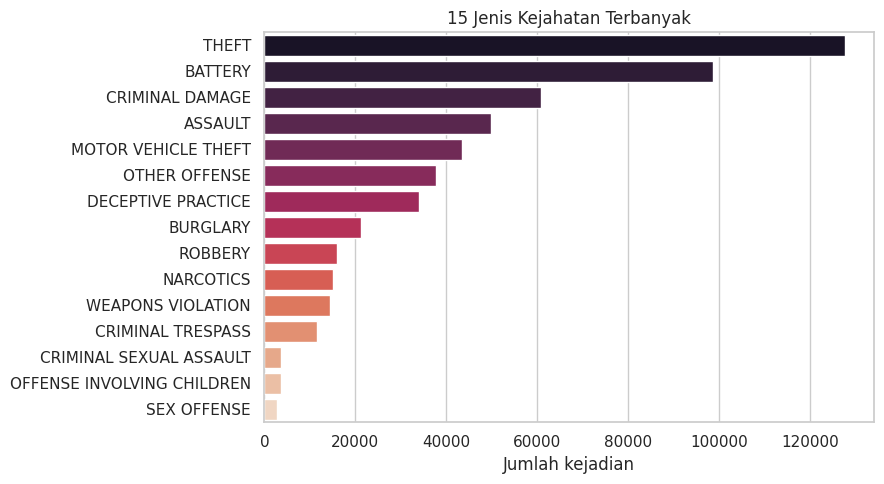

In [8]:
top_types = df["Primary Type"].value_counts().head(15)

plt.figure(figsize=(9, 5))
sns.barplot(x=top_types.values, y=top_types.index, hue=top_types.index,
            palette="rocket", legend=False)
plt.title("15 Jenis Kejahatan Terbanyak")
plt.xlabel("Jumlah kejadian"); plt.ylabel("")
plt.tight_layout(); plt.show()

## 3.2 Pola Temporal

Perhatikan baik-baik pola per jam dan per hari. Pola inilah yang membuat fitur
temporal menjadi penting.

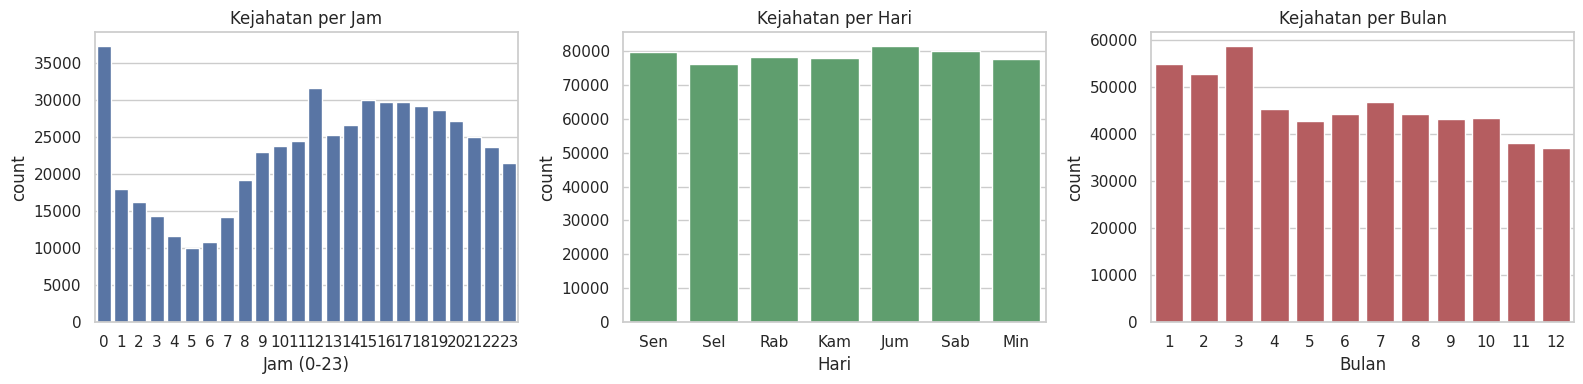

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Per jam
sns.countplot(x="hour", data=df, ax=axes[0], color="#4C72B0")
axes[0].set_title("Kejahatan per Jam"); axes[0].set_xlabel("Jam (0-23)")

# Per hari dalam seminggu
labels_dow = ["Sen","Sel","Rab","Kam","Jum","Sab","Min"]
sns.countplot(x="dow", data=df, order=[0,1,2,3,4,5,6], ax=axes[1], color="#55A868")
axes[1].set_title("Kejahatan per Hari"); axes[1].set_xlabel("Hari")
axes[1].set_xticks(range(7)); axes[1].set_xticklabels(labels_dow)

# Per bulan
sns.countplot(x="month", data=df, ax=axes[2], color="#C44E52")
axes[2].set_title("Kejahatan per Bulan"); axes[2].set_xlabel("Bulan")

plt.tight_layout(); plt.show()

Analisis: jam -> kejahatan mencapai titik terendah pada dini hari (jam 4–6) dan memuncak pada sore hingga malam (jam 15–19). Namun, lonjakan ekstrem pada jam 00 (~37.500 kejadian, dua kali lipat jam 01) tidak diinterpretasikan sebagai pola kriminal, melainkan hanya pencatatan (lihat poin 3.4)
hari -> Distribusi antar hari relatif seragam (selisih tertinggi–terendah hanya ~6%). Temuan ini sekilas menyiratkan bahwa hari tidak informatif. Namun, analisis bivariat (heatmap jam × hari) pada 3.5 mengungkap bahwa pengaruh hari justru ada: Pada akhir pekan, aktivitas dini hari meningkat sementara puncak sore menurun. Jika diagregasikan ke total harian, jumlah kejahatan per hari akan terlihat seragam dan malah tidak terlihat penting untuk diencode.
bulan -> Terdapat tren menurun dari awal ke akhir tahun. Namun, pola ini kemungkinan besar dikarenakan dataset yang dipakai hanya mencakup bulan Januari–April untuk tahun 2026, sementara pada tahun 2024-2025 mencakup bulan Januari-Desember, sehingga bulan-bulan awal memperoleh kontribusi dari tiga tahun sementara bulan akhir hanya dari dua tahun. Karena itu, nterpretasi bulan dirasa kurang valid untuk digunakan.

## 3.3 Pola Spasial

Sebaran koordinat memperlihatkan **konsentrasi** kejahatan. `hexbin` cocok untuk
menunjukkan kepadatan tanpa terganggu jutaan titik yang saling menimpa.

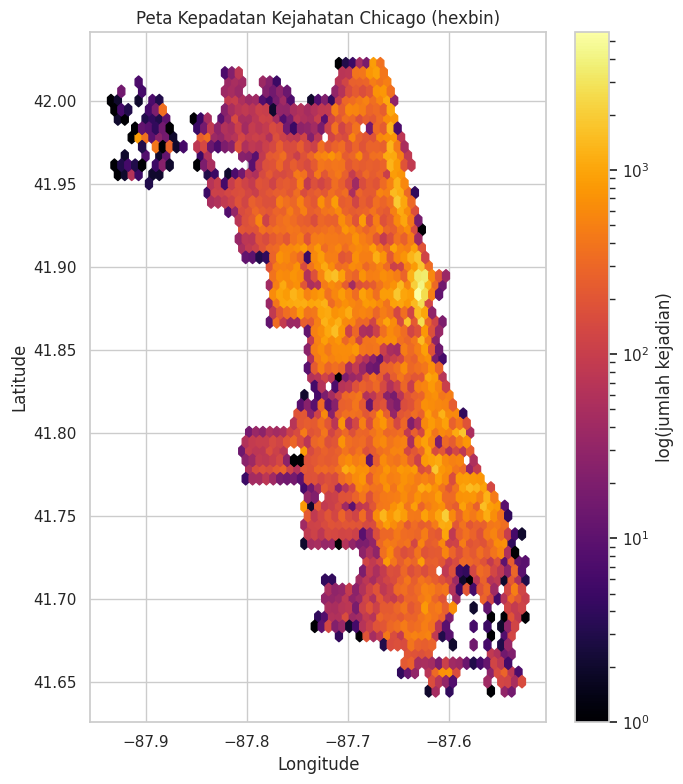

In [10]:
plt.figure(figsize=(7, 8))
hb = plt.hexbin(df["Longitude"], df["Latitude"], gridsize=60,
                cmap="inferno", mincnt=1, bins="log")
plt.colorbar(hb, label="log(jumlah kejadian)")
plt.title("Peta Kepadatan Kejahatan Chicago (hexbin)")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.tight_layout(); plt.show()

Konsentrasi tertinggi (>10³ kejadian per bin) terpusat di koridor tengah-utara, wilayah pusat kota dan sekitarnya, dengan jalur kepadatan tinggi yang memanjang ke selatan. Wilayah tepi kota menunjukkan kepadatan jauh lebih rendah (<10¹). Terdapat pula kantong aktivitas yang terpisah secara geografis di barat laut, kemungkinan besar area bandara.
Perlu dicatat bahwa peta ini menggunakan skala warna logaritmik. Hal ini dikarenakan jika memakai skala linear, seluruh kota akan tampak gelap seragam kecuali beberapa bin hotspot. Temuan ini konsisten dengan kurva konsentrasi kumulatif, di mana ~37% sel terpadat menampung 80% kejadian. Oleh karena itu, bisa ditarik sebuah kesimpulan, yaitu ketimpangan distribusi yang ekstrem ini menjadi pertimbangan penting pada tahap normalisasi Risk Score, karena min-max scaling langsung berpotensi menekan mayoritas sel ke rentang skor sangat rendah sementara hanya segelintir hotspot yang memperoleh skor tinggi. Transformasi logaritmik atau pendekatan berbasis persentil kemungkinan lebih tepat.

# 3.4 Distribusi Menit

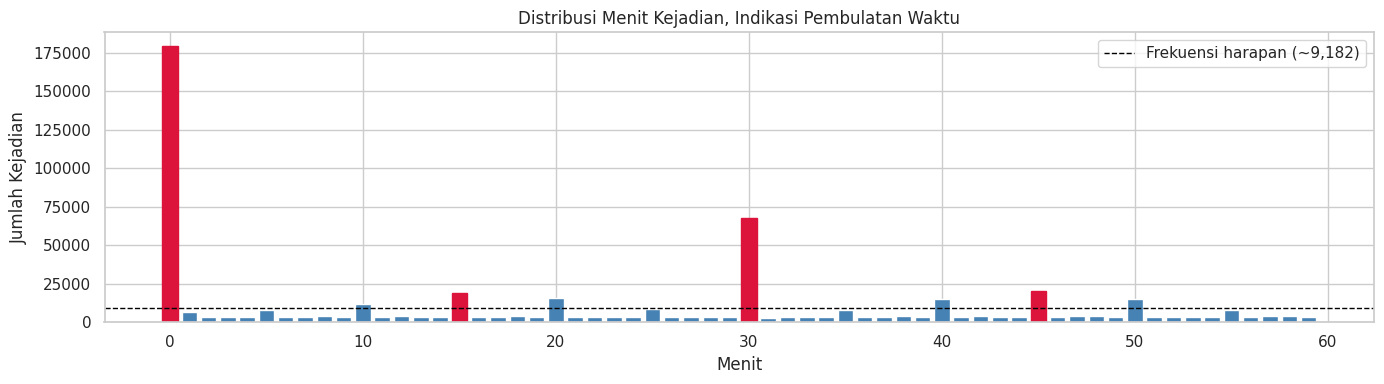

Frekuensi harapan per menit : 9,182
Menit 0                     : 179,214 (19.5x harapan)
Menit 30                    : 67,766 (7.4x harapan)

% kejadian di menit 'bulat' (0/15/30/45): 52.0%
% kejadian di menit 0 saja              : 32.5%
(Kalau presisi, harusnya ~6.7% dan ~1.7%)


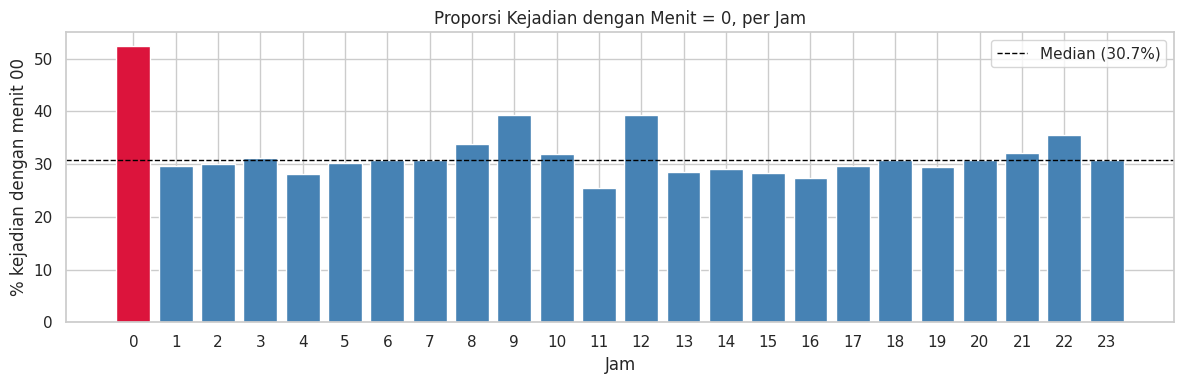


Jam 0  : 52.4% kejadian punya menit 00
Median jam lain: 30.7%


In [11]:

minute_counts = df["Datetime"].dt.minute.value_counts().sort_index()
expected = len(df) / 60
plt.figure(figsize=(14, 4))
bars = plt.bar(minute_counts.index, minute_counts.values, color="steelblue")

for m in [0, 15, 30, 45]:
    if m in minute_counts.index:
        bars[m].set_color("crimson")

plt.axhline(expected, color="black", ls="--", lw=1,
            label=f"Frekuensi harapan (~{expected:,.0f})")
plt.title("Distribusi Menit Kejadian, Indikasi Pembulatan Waktu")
plt.xlabel("Menit")
plt.ylabel("Jumlah Kejadian")
plt.legend()
plt.tight_layout()
plt.show()

round_minutes = [0, 15, 30, 45]
pct_round = df["Datetime"].dt.minute.isin(round_minutes).mean() * 100
pct_min0 = (df["Datetime"].dt.minute == 0).mean() * 100

print(f"Frekuensi harapan per menit : {expected:,.0f}")
print(f"Menit 0                     : {minute_counts[0]:,} "
      f"({minute_counts[0]/expected:.1f}x harapan)")
print(f"Menit 30                    : {minute_counts[30]:,} "
      f"({minute_counts[30]/expected:.1f}x harapan)")
print(f"\n% kejadian di menit 'bulat' (0/15/30/45): {pct_round:.1f}%")
print(f"% kejadian di menit 0 saja              : {pct_min0:.1f}%")
print(f"(Kalau presisi, harusnya ~6.7% dan ~1.7%)")


pct_min0_per_hour = df.groupby(df["Datetime"].dt.hour).apply(
    lambda x: (x["Datetime"].dt.minute == 0).mean() * 100
)

plt.figure(figsize=(12, 4))
colors = ["crimson" if h == 0 else "steelblue" for h in pct_min0_per_hour.index]
plt.bar(pct_min0_per_hour.index, pct_min0_per_hour.values, color=colors)
plt.axhline(pct_min0_per_hour.median(), color="black", ls="--", lw=1,
            label=f"Median ({pct_min0_per_hour.median():.1f}%)")
plt.title("Proporsi Kejadian dengan Menit = 0, per Jam")
plt.xlabel("Jam")
plt.ylabel("% kejadian dengan menit 00")
plt.xticks(range(24))
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nJam 0  : {pct_min0_per_hour[0]:.1f}% kejadian punya menit 00")
print(f"Median jam lain: {pct_min0_per_hour.drop(0).median():.1f}%")

Analisis distribusi menit mengungkap bahwa:
1. Sekitar 30% kejadian di seluruh jam tercatat pada menit ke-0, jauh di atas ekspetasi ~1,7% bila waktu presisi. Hal ini konsisten dengan pernyatan di website resmi Chicago Data Portal (https://data.cityofchicago.org/Public-Safety/Crimes-2001-to-Present/ijzp-q8t2/about_data) yang menyatakan bahwa isi field date terkadang merupakan 'terkadang estimasi terbaik'.
2. Jam 00 menunjukkan proporsi menit 00 sebesar 52.4%, jauh melampaui median lainnya (~30,7%) dan merupakan outlier tunggal dalam distribusi. Ini mengindikasikan bahwa 00:00:00 berfungsi sebagai nilai default ketika waktu kejadian sama sekali tidak diketahui (Dalam desain database, biasanya field timestamp harus berisi DD-MM-YYY HH:MM:SS. Maka dari itu, jika tidak diketahui waktunya secara presisi, kemungkinan besar polisinya hanya mencatat tanggal dan tidak mengisi waktu secara benar. Oleh karena itu, jam kejadian dibiarkan default, yaitu 00:00:00). Maka dari itu,
Konsekuensi desain:
(1). granularitas temporal dibatasi pada level jam, karena resolusi yang lebih halus tidak didukung kualitas data.
(2). puncak kejadian pada jam 00 dalam heatmap tidak diinterpretasikan sebagai pola kriminal yang sebenarnya, hanya sebagai pencatatan.

# 3.5 Heatmap jam x hari

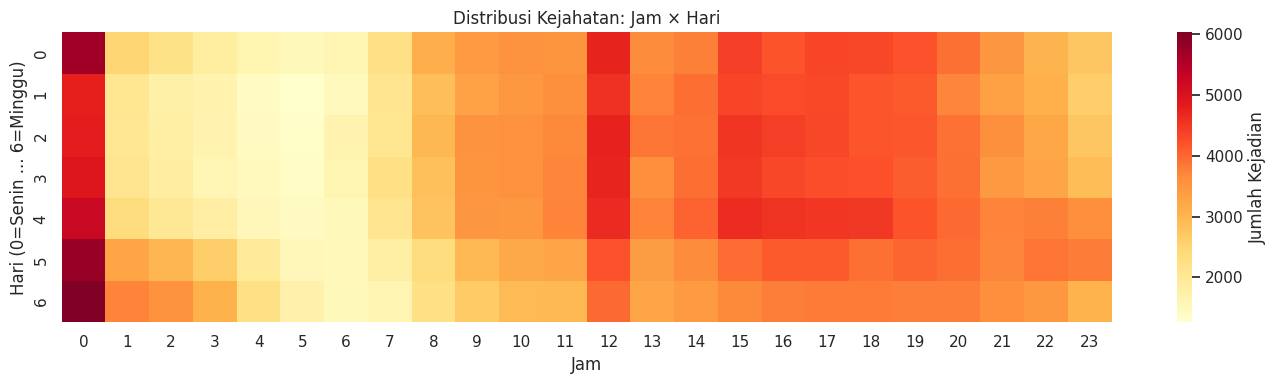

In [12]:
pivot = df.pivot_table(index="dow", columns="hour",
                       values="Primary Type", aggfunc="count")

plt.figure(figsize=(14, 4))
sns.heatmap(pivot, cmap="YlOrRd", cbar_kws={"label": "Jumlah Kejadian"})
plt.title("Distribusi Kejahatan: Jam × Hari")
plt.xlabel("Jam")
plt.ylabel("Hari (0=Senin ... 6=Minggu)")
plt.tight_layout()
plt.show()

Distribusi kejahatan menunjukkan pola siklikal: aktivitas terendah pada dini hari (jam 3-6), meningkat sepanjang pagi, dan memuncak pada sore hingga malam (jam 15-20). Namun, pola ini tidak seragam di seluruh hari. Pada akhir pekan (Sabtu-Minggu), aktivitas dini hari (jam 1-4) meningkat secara signifikan dibanding hari kerja, sementara puncak sore hari justru lebih tajam pada hari kerja, konsisten dengan pola aktivitas sosial yang berbeda antara weekday dan weekend.
Temuan ini menjadi dasar keputusan untuk meng-encode hour dan dow secara terpisah karena keduanya membawa informasi yang tidak redundan, karena efek jam bergantung pada hari.
Perlu dicatat bahwa jam 00:00 menunjukkan konsentrasi yang menonjol di seluruh hari. Pemeriksaan lebih lanjut (mengutip dari website resmi chicago crime: https://data.cityofchicago.org/Public-Safety/Crimes-2001-to-Present/ijzp-q8t2/about_data) mengungkap bahwa ini adalah akibat dari adanya pembulatan waktu (lihat analisis distribusi menit pada 3.4), bukan pola kriminal sebenarnya.

# 3.6 Jenis kejahatan x jam


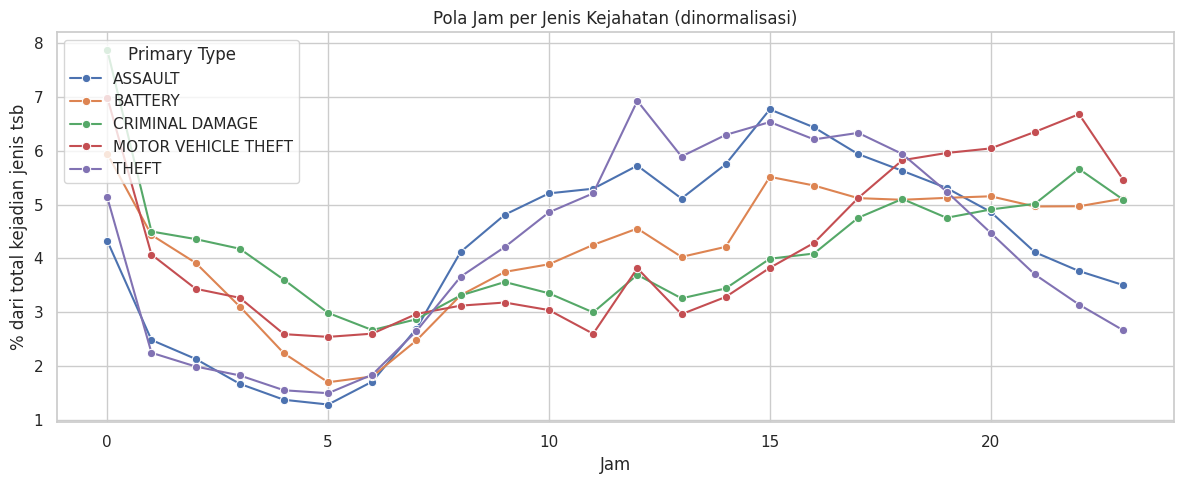

In [13]:
top5 = df["Primary Type"].value_counts().head(5).index
sub = df[df["Primary Type"].isin(top5)]

hourly = sub.groupby(["Primary Type", "hour"]).size().reset_index(name="count")
# normalisasi per jenis biar bisa dibandingkan bentuk polanya
hourly["pct"] = hourly.groupby("Primary Type")["count"].transform(lambda x: x / x.sum() * 100)

plt.figure(figsize=(12, 5))
sns.lineplot(data=hourly, x="hour", y="pct", hue="Primary Type", marker="o")
plt.title("Pola Jam per Jenis Kejahatan (dinormalisasi)")
plt.xlabel("Jam")
plt.ylabel("% dari total kejadian jenis tsb")
plt.tight_layout()
plt.show()

Bentuk kurva masing-masing kejahatan berbeda secara substantif.
Kontras paling tajam terlihat antara kejahatan THEFT dan MOTOR VEHICLE THEFT. THEFT memuncak pada tengah hari (7% pada jam 12) dan menurun drastis di malam hari (~2,7% pada jam 23), konsisten dengan kebutuhan akan keramaian dan aktivitas komersial. Sebaliknya, MOTOR VEHICLE THEFT justru memuncak pada malam hari (6,7% pada jam 22). Hal ini konsisten dengan kebutuhan akan kondisi gelap dan sepi. BATTERY menunjukkan pola yang lebih datar dengan aktivitas yang tetap tinggi hingga larut malam. Temuan ini membuktikan bahwa komposisi jenis kejahatan bervariasi secara sistematis menurut jam. Konsekuensinya, diperlukan pembobotan severity agar hasil analisis risiko yang didapatkan benar-benar representatif terhadap dataset sebenarnya (pencurian kendaraan pribadi tentu lebih berat dan tidak benar berdasarkan norma sosial manusia dibandingkan pencurian biasa sehingga bisa dibilang lebih mengancam dan berisiko). Sebuah jam dengan lebih sedikit kejadian namun didominasi kejahatan berat dapat memperoleh Risk Score lebih tinggi dibanding jam dengan banyak kejadian ringan.

# 3.7 Konsentrasi Spasial Kejahatan

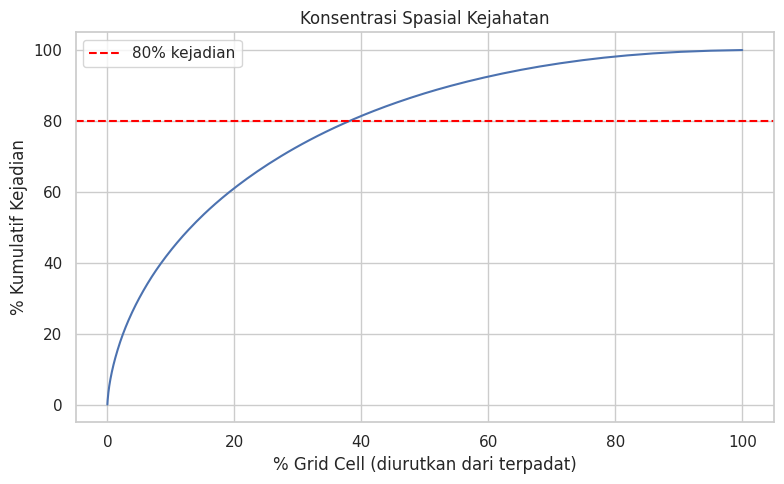

Total grid cell        : 20,125
Median kejadian per cell: 15
Cell dengan <5 kejadian : 19.0%
38% cell terpadat menampung 80% kejadian


In [14]:
cell_counts = df.groupby("cell_id").size().sort_values(ascending=False)

cum_pct = cell_counts.cumsum() / cell_counts.sum() * 100
cell_pct = np.arange(1, len(cell_counts) + 1) / len(cell_counts) * 100

plt.figure(figsize=(8, 5))
plt.plot(cell_pct, cum_pct)
plt.axhline(80, color="red", ls="--", label="80% kejadian")
plt.title(f"Konsentrasi Spasial Kejahatan")
plt.xlabel("% Grid Cell (diurutkan dari terpadat)")
plt.ylabel("% Kumulatif Kejadian")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Total grid cell        : {len(cell_counts):,}")
print(f"Median kejadian per cell: {cell_counts.median():.0f}")
print(f"Cell dengan <5 kejadian : {(cell_counts < 5).mean()*100:.1f}%")

idx_80 = np.searchsorted(cum_pct, 80)
print(f"{cell_pct[idx_80]:.0f}% cell terpadat menampung 80% kejadian")

Dengan grid metrik 150m × 150m, wilayah Chicago terbagi menjadi 20.125 sel. Kurva konsentrasi menunjukkan bahwa sekitar [X]% sel terpadat menampung 80% dari seluruh kejadian.

Namun, median kejadian per sel hanya 15, dan 19% sel memiliki kurang dari 5 kejadian. Kepadatan yang tipis ini berarti Risk Score yang dihitung semata-mata dari kejadian di dalam sel itu sendiri akan sangat sensitif terhadap fluktuasi kecil. Maka dari itu, temuan ini menjadi justifikasi utama penerapan spatial decay. Dengan membiarkan sel bertetangga saling berkontribusi (dengan bobot menurun terhadap jarak), estimasi risiko untuk sel berdata tipis menjadi lebih stabil, dan sel yang bersebelahan dengan hotspot tidak keliru dinilai aman hanya karena batas grid yang bersifat artifisial.

# 4. Feature Engineering


In [15]:
EXCLUDED_TYPES = {
    "NON-CRIMINAL",
    "NON-CRIMINAL (SUBJECT SPECIFIED)",
    "NON - CRIMINAL",
    "OTHER OFFENSE",
    "DECEPTIVE PRACTICE",
    "PUBLIC INDECENCY",
    "OBSCENITY",
    "CONCEALED CARRY LICENSE VIOLATION",
    "LIQUOR LAW VIOLATION",
    "GAMBLING",
    "INTERFERENCE WITH PUBLIC OFFICER",
}

base_severity = {
    "HOMICIDE": 100,
    "CRIMINAL SEXUAL ASSAULT": 90,
    "CRIM SEXUAL ASSAULT": 90,
    "HUMAN TRAFFICKING": 90,
    "KIDNAPPING": 85,

    "ROBBERY": 70,
    "ARSON": 65,
    "SEX OFFENSE": 60,
    "OFFENSE INVOLVING CHILDREN": 60,
    "BATTERY": 50,
    "ASSAULT": 45,
    "INTIMIDATION": 45,
    "STALKING": 40,

    "WEAPONS VIOLATION": 55,
    "NARCOTICS": 35,
    "OTHER NARCOTIC VIOLATION": 35,

    "BURGLARY": 45,
    "MOTOR VEHICLE THEFT": 35,
    "THEFT": 25,

    "CRIMINAL TRESPASS": 20,
    "CRIMINAL DAMAGE": 15,
    "CRIMINAL DEFACEMENT": 10,

    "PROSTITUTION": 20,
    "PUBLIC PEACE VIOLATION": 20,
}

## Severity Table

Severity score dibangun di sini karena diperlukan untuk membentuk fitur agregat
spasial pada 4.2. Penjelasan lengkap mengenai kerangka penilaian, justifikasi
skor, dan transformasi non-linear dibahas pada 5.1.

In [16]:
def severity_modifier(desc, primary_type=None):
    d = str(desc).upper()
    mod = 0

    if primary_type != "WEAPONS VIOLATION":
        if "HANDGUN" in d or "FIREARM" in d:
            mod += 25
        elif "KNIFE" in d or "CUTTING INSTRUMENT" in d:
            mod += 18
        elif "DANGEROUS WEAPON" in d:
            mod += 15

    if "AGGRAVATED" in d or "AGG." in d:
        mod += 12

    if "HOME INVASION" in d:
        mod += 40

    if "HIJACKING" in d:
        mod += 15

    if "SERIOUS INJURY" in d:
        mod += 10

    if "POCKET-PICKING" in d or "PURSE-SNATCHING" in d or "FROM PERSON" in d:
        mod += 15

    if primary_type == "HOMICIDE" and "RECKLESS" in d:
        mod -= 30

    if "ATTEMPT" in d:
        mod -= 12

    if "FROM MOTOR VEHICLE" in d or "TO VEHICLE" in d:
        mod -= 5

    return mod


def compute_severity(row):
    pt = row["Primary Type"]
    if pt in EXCLUDED_TYPES:
        return np.nan
    base = base_severity.get(pt, 20)
    return np.clip(base + severity_modifier(row["Description"], pt), 1, 100)


before = len(df)
df = df[~df["Primary Type"].isin(EXCLUDED_TYPES)].copy()
print(f"Dibuang {before - len(df):,} baris non-spasial "
      f"({(before - len(df)) / before * 100:.2f}%)")
print(f"Sisa: {len(df):,} baris")

df["severity"] = df.apply(compute_severity, axis=1)

SEVERITY_EXPONENT = 2
df["severity_weighted"] = (df["severity"] / 100) ** SEVERITY_EXPONENT * 100

print(f"\nSeverity dasar    : {df['severity'].min():.0f} - {df['severity'].max():.0f} "
      f"(mean {df['severity'].mean():.1f})")
print(f"Severity weighted : {df['severity_weighted'].min():.1f} - "
      f"{df['severity_weighted'].max():.1f} (mean {df['severity_weighted'].mean():.1f})")

Dibuang 74,915 baris non-spasial (13.60%)
Sisa: 475,981 baris

Severity dasar    : 10 - 100 (mean 38.9)
Severity weighted : 1.0 - 100.0 (mean 19.4)


## 4.1 Fitur Temporal: Cyclical Encoding

Waktu bersifat **siklikal**: jam `23:00` sebenarnya *berdekatan* dengan `00:00`, tetapi
jika kita pakai angka mentah (`23` vs `0`) model akan menganggapnya **berjauhan**
(selisih 23!). Solusi umum: petakan setiap nilai siklikal ke **lingkaran** dengan `sin` & `cos`:

$$x_{\sin} = \sin\!\left(\frac{2\pi \cdot v}{P}\right), \qquad x_{\cos} = \cos\!\left(\frac{2\pi \cdot v}{P}\right)$$

dengan $P$ = panjang siklus (24 untuk jam, 7 untuk hari, 12 untuk bulan).


In [17]:
def cyclical_encode(values, period):
    # Ubah nilai siklikal menjadi pasangan (sin, cos)
    radians = 2 * np.pi * values / period
    return np.sin(radians), np.cos(radians)

df["hour_sin"], df["hour_cos"] = cyclical_encode(df["hour"], 24)
df["dow_sin"],  df["dow_cos"]  = cyclical_encode(df["dow"],  7)
df["is_weekend"] = (df["dow"] >= 5).astype(int)
df[["hour", "hour_sin", "hour_cos", "dow", "dow_sin", "dow_cos"]].head()

,hour,hour_sin,hour_cos,dow,dow_sin,dow_cos
0,0,0.0,1.0,5,-0.974928,-0.222521
2,0,0.0,1.0,5,-0.974928,-0.222521
4,0,0.0,1.0,5,-0.974928,-0.222521
5,0,0.0,1.0,5,-0.974928,-0.222521
6,0,0.0,1.0,5,-0.974928,-0.222521


is_weekend ditambahkan meskipun secara teknis redundan dengan dow_sin/dow_cos. Alasannya, representasi siklikal memperlakukan transisi Jumat ke Sabtu identik dengan Selasa ke Rabu, yaitu jarak yang sama pada lingkaran. Padahal temuan EDA (3.5) menunjukkan bahwa pola dini hari Sabtu berbeda tajam dari Jumat, sementara Selasa dan Rabu nyaris identik. Fitur biner ini secara eksplisit menandai batas tersebut, informasi yang tidak tertangkap dengan baik oleh representasi siklikal.

Cek jarak antar-jam pada bidang (sin, cos):
`23:00` seharusnya lebih dekat ke `00:00` daripada ke `12:00`.

Jarak 23:00 -> 00:00 = 0.261  (harusnya KECIL)
Jarak 00:00 -> 12:00 = 2.000  (harusnya BESAR)


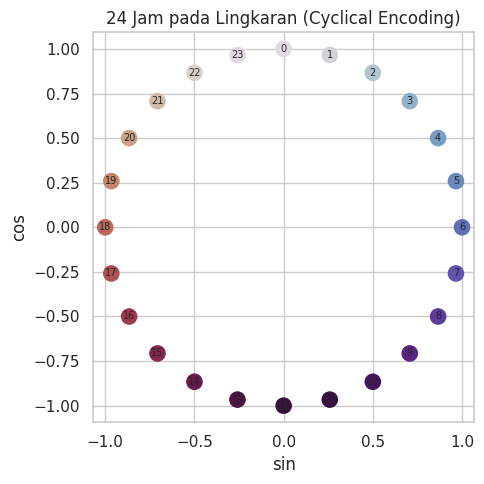

In [18]:
def point(v, p): return np.array(cyclical_encode(np.array([v]), p)).ravel()

d_23_to_0 = np.linalg.norm(point(23, 24) - point(0, 24))
d_0_to_12 = np.linalg.norm(point(0, 24)  - point(12, 24))
print(f"Jarak 23:00 -> 00:00 = {d_23_to_0:.3f}  (harusnya KECIL)")
print(f"Jarak 00:00 -> 12:00 = {d_0_to_12:.3f}  (harusnya BESAR)")

# Visualisasi 24 jam sebagai lingkaran
hs, hc = cyclical_encode(np.arange(24), 24)
plt.figure(figsize=(5,5))
plt.scatter(hs, hc, c=np.arange(24), cmap="twilight", s=120)
for h in range(24):
    plt.annotate(str(h), (hs[h], hc[h]), ha="center", va="center", fontsize=7)
plt.title("24 Jam pada Lingkaran (Cyclical Encoding)")
plt.xlabel("sin"); plt.ylabel("cos"); plt.axis("equal")
plt.tight_layout(); plt.show()

## 4.2 Fitur Spasial: Grid Aggregation


In [19]:
cell_features = df.groupby("cell_id").agg(
    n_crimes=("severity", "size"),
    mean_severity=("severity", "mean"),
    max_severity=("severity", "max"),
    n_distinct_types=("Primary Type", "nunique"),
).reset_index()

VIOLENT_TYPES = {
    "HOMICIDE", "CRIMINAL SEXUAL ASSAULT", "HUMAN TRAFFICKING", "KIDNAPPING",
    "ROBBERY", "BATTERY", "ASSAULT", "SEX OFFENSE", "ARSON",
    "OFFENSE INVOLVING CHILDREN", "INTIMIDATION", "STALKING",
}

df["is_violent"] = df["Primary Type"].isin(VIOLENT_TYPES).astype(int)
cell_features["pct_violent"] = (df.groupby("cell_id")["is_violent"]
                                  .mean().values * 100)
cell_features["density_ratio"] = (cell_features["n_crimes"] /
                                  cell_features["n_crimes"].mean())

print(f"Jumlah sel: {len(cell_features):,}")
print(cell_features.describe().round(2).to_string())
cell_features.head()

Jumlah sel: 19,863
       n_crimes  mean_severity  max_severity  n_distinct_types  pct_violent  density_ratio
count  19863.00       19863.00      19863.00          19863.00     19863.00       19863.00
mean      23.96          38.20         73.01              5.95        35.13           1.00
std       39.35           9.83         23.56              3.14        23.45           1.64
min        1.00          10.00         10.00              1.00         0.00           0.04
25%        5.00          32.27         50.00              3.00        18.92           0.21
50%       13.00          38.16         82.00              6.00        34.69           0.54
75%       28.00          43.75         95.00              8.00        50.00           1.17
max     1162.00         100.00        100.00             18.00       100.00          48.49


,cell_id,n_crimes,mean_severity,max_severity,n_distinct_types,pct_violent,density_ratio
0,-48387_30944,6,44.500000,77,5,16.666667,0.250384
1,-48387_30945,3,47.333333,82,3,33.333333,0.125192
2,-48387_30946,1,15.000000,15,1,0.000000,0.041731
3,-48387_30947,1,35.000000,35,1,0.000000,0.041731
4,-48387_30948,4,31.250000,50,4,25.000000,0.166923


### Perbandingan Ukuran Grid

In [20]:
def grid_stats(size_m):
    gx = (df["x_m"] // size_m).astype(int)
    gy = (df["y_m"] // size_m).astype(int)
    counts = df.groupby([gx, gy]).size()
    return {
        "ukuran_sel": f"{size_m}m",
        "n_sel": len(counts),
        "median_kejadian": counts.median(),
        "pct_sel_sepi(<5)": round((counts < 5).mean() * 100, 1)
    }

comparison = pd.DataFrame([grid_stats(s) for s in [50, 100, 150, 250, 500]])
print(comparison.to_string(index=False))

ukuran_sel  n_sel  median_kejadian  pct_sel_sepi(<5)
       50m  60147              4.0              57.5
      100m  36768              6.0              39.1
      150m  19863             13.0              21.7
      250m   8147             35.0              10.5
      500m   2341            138.0               5.9


Justifikasi ukuran grid yang dipilih berdasarkan tabel di atas dijelaskan di README.md.

# 5. Pseudo-Labeling

## 5.1 Severity Scoring

Setiap kejahatan diberi skor keparahan berdasarkan kombinasi Primary Type + Description.

### 5.1.1 Struktur jenis kejahatan


In [21]:
print(f"Total Primary Type         : {df['Primary Type'].nunique()}")
combos = df.groupby(["Primary Type", "Description"]).size().sort_values(ascending=False)
print(f"Total kombinasi (Type+Desc): {len(combos):,}")

pt_counts = df["Primary Type"].value_counts()
pt_pct = (pt_counts / len(df) * 100).round(2)

print("\n=== Distribusi Primary Type ===")
print(pd.DataFrame({"count": pt_counts, "pct": pt_pct}).to_string())

print("\n=== Cakupan Kumulatif ===")
for n in [5, 10, 15, 20]:
    print(f"Top {n:2d} Primary Type mencakup {pt_pct.head(n).sum():.1f}% data")

Total Primary Type         : 22
Total kombinasi (Type+Desc): 245

=== Distribusi Primary Type ===
                             count    pct
Primary Type                             
THEFT                       127679  26.82
BATTERY                      98769  20.75
CRIMINAL DAMAGE              60837  12.78
ASSAULT                      49903  10.48
MOTOR VEHICLE THEFT          43385   9.11
BURGLARY                     21345   4.48
ROBBERY                      16003   3.36
NARCOTICS                    15157   3.18
WEAPONS VIOLATION            14424   3.03
CRIMINAL TRESPASS            11649   2.45
CRIMINAL SEXUAL ASSAULT       3639   0.76
OFFENSE INVOLVING CHILDREN    3583   0.75
SEX OFFENSE                   2848   0.60
PUBLIC PEACE VIOLATION        2303   0.48
STALKING                      1222   0.26
HOMICIDE                      1133   0.24
ARSON                          934   0.20
PROSTITUTION                   527   0.11
INTIMIDATION                   374   0.08
KIDNAPPING          

Dari output tersebut, terlihat bahwa  justifikasi mendalam bisa difokuskan ke Top 10 (mencakup 92% data). Sisanya (21 jenis, cuma 8% data) bisa dinilai dengan kerangka umum tanpa analisis per-kombinasi.

### 5.1.2 Variasi Description dalam setiap Primary Type

In [22]:
for pt in df["Primary Type"].value_counts().head(10).index:
    print(f"\n{'='*65}")
    print(f"{pt}  ({df[df['Primary Type']==pt].shape[0]:,} kejadian)")
    print('='*65)
    descs = df[df["Primary Type"] == pt]["Description"].value_counts().head(8)
    for d, c in descs.items():
        pct = c / df[df["Primary Type"]==pt].shape[0] * 100
        print(f"  {c:7,} ({pct:5.1f}%)  {d}")


THEFT  (127,679 kejadian)
   38,068 ( 29.8%)  $500 AND UNDER
   34,828 ( 27.3%)  OVER $500
   30,433 ( 23.8%)  RETAIL THEFT
   10,546 (  8.3%)  FROM BUILDING
    9,644 (  7.6%)  THEFT FROM MOTOR VEHICLE
    2,791 (  2.2%)  POCKET-PICKING
      747 (  0.6%)  ATTEMPT THEFT
      514 (  0.4%)  PURSE-SNATCHING

BATTERY  (98,769 kejadian)
   43,730 ( 44.3%)  DOMESTIC BATTERY SIMPLE
   34,787 ( 35.2%)  SIMPLE
    4,158 (  4.2%)  AGGRAVATED - OTHER DANGEROUS WEAPON
    2,950 (  3.0%)  AGGRAVATED - HANDGUN
    2,278 (  2.3%)  AGG. DOMESTIC BATTERY - HANDS, FISTS, FEET, SERIOUS INJURY
    2,032 (  2.1%)  AGGRAVATED DOMESTIC BATTERY - OTHER DANGEROUS WEAPON
    1,825 (  1.8%)  AGGRAVATED - KNIFE / CUTTING INSTRUMENT
    1,544 (  1.6%)  AGGRAVATED P.O. - HANDS, FISTS, FEET, NO / MINOR INJURY

CRIMINAL DAMAGE  (60,837 kejadian)
   33,067 ( 54.4%)  TO VEHICLE
   25,341 ( 41.7%)  TO PROPERTY
    1,236 (  2.0%)  CRIMINAL DEFACEMENT
    1,034 (  1.7%)  TO CITY OF CHICAGO PROPERTY
      133 (  0.2%)  

### 5.1.3 Analisis Struktur Data

Distribusi sangat timpang. Dari 31 Primary Type yang ada, 10 jenis teratas mencakup 91,7% seluruh kejadian, sementara 15 teratas mencakup 98,2%. Konsekuensinya, justifikasi mendalam difokuskan pada jenis-jenis dominan. Kesalahan penilaian pada jenis berfrekuensi sangat rendah (misalnya GAMBLING, 0,01% data) berdampak marjinal terhadap Risk Score akhir, sementara kesalahan pada THEFT (23,18%) berdampak besar.

Pemeriksaan variasi Description dalam setiap Primary Type menunjukkan perbedaan tingkat keparahan yang substansial di dalam kategori yang sama:

- BATTERY: 79,5% berupa kekerasan tanpa senjata (`SIMPLE` dan `DOMESTIC BATTERY SIMPLE`), namun terdapat pula varian bersenjata seperti `AGGRAVATED - HANDGUN` (3,0%) dan `AGGRAVATED - KNIFE` (1,8%).
- ROBBERY (2,90% data): 37,9% adalah `ARMED - HANDGUN`, sementara 28,6% adalah `STRONG ARM - NO WEAPON`.
- BURGLARY (3,87% data): mayoritas berupa `FORCIBLE ENTRY` (38,9%) dan `BURGLARY FROM MOTOR VEHICLE` (29,3%), namun terdapat `HOME INVASION` (2,5%) yaitu masuk paksa ke rumah saat penghuni berada di dalam.

Dengan demikian, severity scoring harus mempertimbangkan kombinasi `Primary Type` dan `Description`. Pola penamaan Description juga konsisten dan dapat dimanfaatkan. Kata kunci seperti `AGGRAVATED`, `HANDGUN`, `KNIFE`, `ATTEMPT`, dan `HOME INVASION` muncul berulang lintas Primary Type dengan makna yang seragam.

Dua isu desain:

1. Kategori terbesar dalam BATTERY adalah `DOMESTIC BATTERY SIMPLE` (44,3% dari seluruh BATTERY). Kekerasan domestik terjadi di ruang privat dengan target spesifik anggota keluarga berbeda dengan kekerasan di ruang publik yang mengancam siapa pun yang berada di lokasi tersebut. Karena Risk Score dimaksudkan untuk merepresentasikan risiko suatu lokasi bagi orang yang berada di sana, relevansi kekerasan domestik terhadap tujuan ini perlu dipertimbangkan.

2. Sebagian besar `OTHER OFFENSE` (6,87% data) berupa `TELEPHONE THREAT` (19,4%), `HARASSMENT BY TELEPHONE` (15,6%), dan `HARASSMENT BY ELECTRONIC MEANS` (14,9%). Demikian pula `DECEPTIVE PRACTICE` (6,18%) yang didominasi `FINANCIAL IDENTITY THEFT` dan `CREDIT CARD FRAUD`. Kejahatan-kejahatan ini tidak memiliki lokasi fisik yang bermakna, ancaman lewat telepon atau penipuan kartu kredit dicatat pada alamat administratif korban, bukan pada tempat yang secara fisik berbahaya bagi orang yang melintas. Keduanya secara gabungan mencakup 13% data, sehingga perlakuan terhadap data ini akan berdampak secara lumayan signifikan untuk hasil akhir.

### 5.1.4 Kerangka Penilaian Severity

Severity disusun melalui pendekatan gabungan: klasifikasi hukum Illinois, diisi dengan rubrik dampak eksplisit, kemudian disesuaikan berdasarkan kata kunci Description.

Rubrik dampak terdiri dari empat dimensi:

| Dimensi | Bobot | Alasan |
|---|---|---|
| Ancaman nyawa | 40 | Kejahatan berpotensi fatal menimbulkan dampak yang tidak dapat dipulihkan |
| Kekerasan fisik | 25 | Cedera fisik menimbulkan trauma dan kerugian yang melampaui kerugian materi |
| Korban hadir dan terancam | 20 | Membedakan kejahatan yang mengancam orang secara langsung dari kejahatan properti tanpa korban di tempat |
| Senjata terlibat | 15 | Kehadiran senjata meningkatkan potensi eskalasi meskipun belum digunakan |

Skor severity dijangkarkan pada klasifikasi felony Illinois
sebagaimana diatur dalam Unified Code of Corrections (730 ILCS 5/5-4.5), yang
membagi kejahatan berdasarkan rentang hukuman:

| Klasifikasi | Rentang hukuman | Referensi |
|---|---|---|
| First-degree murder | 20 sampai 60 tahun, atau seumur hidup | 730 ILCS 5/5-4.5-20 |
| Class X | 6 sampai 30 tahun, tanpa opsi probation | 730 ILCS 5/5-4.5-25 |
| Class 1 | 4 sampai 15 tahun | 730 ILCS 5/5-4.5-30 |
| Class 2 | 3 sampai 7 tahun | 730 ILCS 5/5-4.5-35 |
| Class 3 | 2 sampai 5 tahun | 730 ILCS 5/5-4.5-40 |
| Class 4 | 1 sampai 3 tahun | 730 ILCS 5/5-4.5-45 |

HOMICIDE diberi skor 100 karena berada dalam kelas tersendiri dengan hukuman
tertinggi. Kejahatan Class X (aggravated criminal sexual assault, armed robbery,
home invasion, aggravated vehicular hijacking, aggravated battery with a firearm,
aggravated kidnapping) ditempatkan pada rentang 85 sampai 95, mencerminkan
statusnya sebagai kejahatan non-homicide terberat yang tidak memungkinkan probation.

Karena Primary Type saja tidak membedakan bentuk aggravated dari bentuk dasar,
skor Class X dicapai melalui kombinasi skor dasar dan modifier Description.
Sebagai contoh, ROBBERY memiliki skor dasar 70, namun ROBBERY dengan Description
"ARMED - HANDGUN" (armed robbery, Class X) memperoleh modifier +25 sehingga
mencapai 95.

Sumber: https://www.ilga.gov/legislation/ilcs/ilcs3.asp?ActID=1999

Kekerasan domestik diberi severity setara dengan kekerasan non-domestik. Penganiayaan tetap merupakan penganiayaan terlepas dari relasi antara pelaku dan korban.

Kejahatan non-spasial dikecualikan. Risk Score merepresentasikan risiko suatu lokasi, yang mengandaikan bahwa kejahatan pada suatu koordinat mencerminkan bahaya yang melekat pada lokasi tersebut. Asumsi ini tidak berlaku untuk DECEPTIVE PRACTICE (penipuan finansial) dan OTHER OFFENSE (didominasi ancaman via telepon dan media elektronik), karena koordinat yang tercatat merupakan alamat administratif korban, bukan tempat terjadinya bahaya fisik. Memasukkannya akan mencemari sinyal spasial, area berpenduduk padat akan tampak berisiko semata karena banyak penghuninya menjadi korban penipuan daring. Kedua kategori mencakup 13,05% data.

### 5.1.5 Transformasi Non-Linear

Skor severity dasar disusun secara linear pada rentang 0 sampai 100. Namun, penggunaan skor linear dalam agregasi mengandung implikasi yang bermasalah. Dengan HOMICIDE bernilai 100 dan THEFT bernilai 25, penjumlahan severity menyiratkan bahwa empat pencurian setara dengan satu pembunuhan. Sebuah blok yang mengalami satu pembunuhan tidak dapat dianggap setara berbahayanya dengan blok yang mengalami empat pencurian barang bernilai rendah.

Karena itu, severity ditransformasi secara kuadratik sebelum diagregasi:

$$\text{severity weighted} = \left(\frac{\text{severity}}{100}\right)^2 \times 100$$

Transformasi ini mempertahankan skala 0 sampai 100 sekaligus memperlebar jarak antar tingkat keparahan secara eksponensial:

| Kejahatan | Severity dasar | Setelah transformasi | Rasio terhadap HOMICIDE |
|---|---|---|---|
| HOMICIDE | 100 | 100,0 | 1x |
| ROBBERY - ARMED HANDGUN | 95 | 90,3 | 1,1x |
| BATTERY - SIMPLE | 50 | 25,0 | 4x |
| THEFT - $500 AND UNDER | 25 | 6,3 | 16x |
| CRIMINAL DAMAGE - TO VEHICLE | 10 | 1,0 | 100x |

Setelah transformasi, dibutuhkan 16 kejadian THEFT untuk menyetarai satu HOMICIDE. Kejahatan berat mendominasi Risk Score secara proporsional dengan tingkat ancamannya dan tidak dapat dikompensasi oleh akumulasi kejahatan ringan.

Eksponen 2 dipilih sebagai titik tengah. Eksponen 3 menghasilkan rasio 64:1 antara HOMICIDE dan THEFT, yang dinilai terlalu ekstrem karena kejahatan properti nyaris tidak berkontribusi terhadap skor akhir.

## 5.2 Temporal Decay

Sebuah kejahatan tidak selamanya relevan secara seragam. Kejadian yang berlangsung kemarin lebih mencerminkan kondisi risiko saat ini dibanding kejadian tiga tahun lalu. Karena itu, kontribusi setiap kejadian terhadap Risk Score dibobot berdasarkan usianya.

### Bentuk fungsi peluruhan
Peluruhan dimodelkan secara eksponensial: $$w(t) = e^{-\lambda t}, \quad \text{dengan } \lambda = \frac{\ln 2}{t_{1/2}}$$

In [23]:
REFERENCE_DATE = df["Datetime"].max()
print(f"Tanggal acuan: {REFERENCE_DATE.date()}")

HALF_LIFE_DAYS = 180

df["days_ago"] = (REFERENCE_DATE - df["Datetime"]).dt.days

lam = np.log(2) / HALF_LIFE_DAYS
df["time_weight"] = np.exp(-lam * df["days_ago"])

df["weighted_severity"] = df["severity_weighted"] * df["time_weight"]

print(f"\nRentang usia kejadian : {df['days_ago'].min()} - {df['days_ago'].max()} hari")
print(f"Rentang bobot temporal: {df['time_weight'].min():.4f} - {df['time_weight'].max():.4f}")

print(f"\nBobot pada beberapa titik waktu:")
for d in [0, 30, 90, 180, 365, 730, 1095]:
    w = np.exp(-lam * d)
    print(f"  {d:5d} hari ({d/365:.1f} tahun): {w:.4f}")

Tanggal acuan: 2026-04-11

Rentang usia kejadian : 0 - 831 hari
Rentang bobot temporal: 0.0408 - 1.0000

Bobot pada beberapa titik waktu:
      0 hari (0.0 tahun): 1.0000
     30 hari (0.1 tahun): 0.8909
     90 hari (0.2 tahun): 0.7071
    180 hari (0.5 tahun): 0.5000
    365 hari (1.0 tahun): 0.2452
    730 hari (2.0 tahun): 0.0601
   1095 hari (3.0 tahun): 0.0147


### Visualisasi

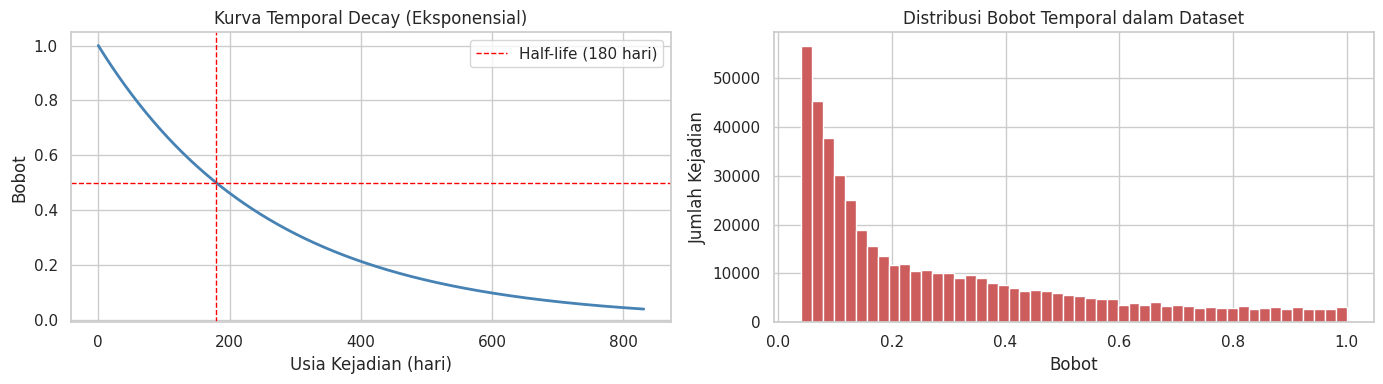

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

days = np.arange(0, df["days_ago"].max() + 1)
weights = np.exp(-lam * days)

axes[0].plot(days, weights, lw=2, color="steelblue")
axes[0].axhline(0.5, color="red", ls="--", lw=1)
axes[0].axvline(HALF_LIFE_DAYS, color="red", ls="--", lw=1,
                label=f"Half-life ({HALF_LIFE_DAYS} hari)")
axes[0].set_title("Kurva Temporal Decay (Eksponensial)")
axes[0].set_xlabel("Usia Kejadian (hari)")
axes[0].set_ylabel("Bobot")
axes[0].legend()

axes[1].hist(df["time_weight"], bins=50, color="indianred", edgecolor="white")
axes[1].set_title("Distribusi Bobot Temporal dalam Dataset")
axes[1].set_xlabel("Bobot")
axes[1].set_ylabel("Jumlah Kejadian")

plt.tight_layout()
plt.show()

Kurva peluruhan berperilaku sesuai spesifikasi: bobot bernilai 1,0 pada kejadian terbaru, tepat 0,5 pada usia 180 hari, dan meluruh secara gradual tanpa mencapai nol. Kejadian tertua dalam subset (831 hari) masih memiliki bobot 0,041, sehingga tetap berkontribusi meski secara marjinal.

Distribusi bobot dalam dataset sangat timpang, dengan mayoritas kejadian menumpuk pada rentang 0,05 hingga 0,15. Hal ini merupakan konsekuensi langsung dari kombinasi rentang subset (831 hari) dan half-life yang relatif pendek (180 hari): seluruh kejadian berusia lebih dari satu tahun memperoleh bobot di bawah 0,25.

Ketimpangan ini sesuai dengan tujuan desain, yaitu memprioritaskan kejadian terkini. Namun terdapat dua konsekuensi yang perlu dicatat:

1. Sel dengan data tipis menjadi lebih rentan. Sebuah sel yang hanya memiliki beberapa kejadian, dan seluruhnya berusia lama, akan memperoleh nilai dasar yang mendekati nol bukan karena lokasi tersebut aman, melainkan karena datanya tua. Hal ini semakin memperkuat kebutuhan akan spatial decay, di mana sel bertetangga memberikan kontribusi yang menstabilkan estimasi.

2. Distribusi risk_raw akan sangat timpang. Tiga komponen yang menyusunnya masing-masing telah timpang: severity setelah transformasi kuadratik, bobot temporal, dan konsentrasi spasial. Efek ketiganya berlipat ganda, sehingga normalisasi dengan min-max scaling berpotensi menekan mayoritas sel ke rentang skor sangat rendah. Pertimbangan ini akan ditindaklanjuti pada tahap normalisasi (5.4).

### Sensitivity Analysis (Half Life)

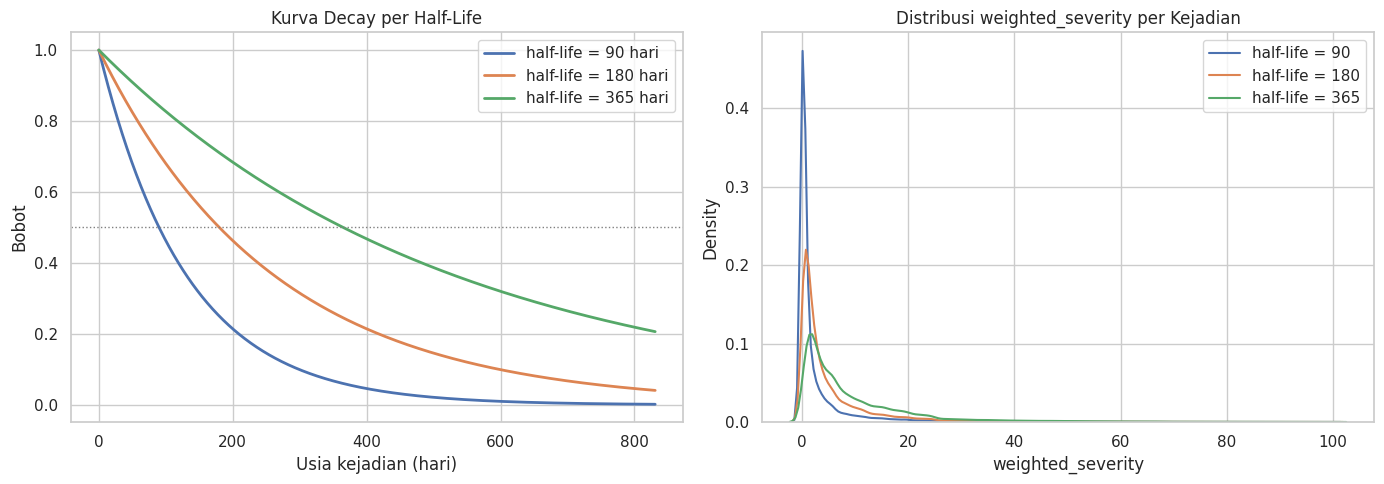

,half_life,bobot_usia_365hr,pct_kontribusi_dari_data_>1th
0,90,0.060,6.30
1,180,0.245,23.03
2,365,0.500,39.49


In [25]:
HALF_LIFE_CANDIDATES = [90, 180, 365]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

days = np.arange(0, df["days_ago"].max() + 1)
for hl in HALF_LIFE_CANDIDATES:
    lam_i = np.log(2) / hl
    axes[0].plot(days, np.exp(-lam_i * days), lw=2, label=f"half-life = {hl} hari")
axes[0].axhline(0.5, color="gray", ls=":", lw=1)
axes[0].set_title("Kurva Decay per Half-Life")
axes[0].set_xlabel("Usia kejadian (hari)"); axes[0].set_ylabel("Bobot")
axes[0].legend()

summary_rows = []
for hl in HALF_LIFE_CANDIDATES:
    lam_i = np.log(2) / hl
    tw_i = np.exp(-lam_i * df["days_ago"])
    ws_i = df["severity_weighted"] * tw_i
    mask_old = df["days_ago"] > 365
    pct_kontribusi_lama = ws_i[mask_old].sum() / ws_i.sum() * 100

    summary_rows.append({
        "half_life": hl,
        "bobot_usia_365hr": round(np.exp(-lam_i * 365), 3),
        "pct_kontribusi_dari_data_>1th": round(pct_kontribusi_lama, 2)
    })

    sns.kdeplot(ws_i, ax=axes[1], label=f"half-life = {hl}", fill=False)

axes[1].set_title("Distribusi weighted_severity per Kejadian")
axes[1].set_xlabel("weighted_severity"); axes[1].legend()
plt.tight_layout(); plt.show()

pd.DataFrame(summary_rows)

half-life 90 hari terlalu agresif (data >1 tahun kontribusinya turun ke nyaris nol sehingga risiko sel sepi jadi makin sepi), half-life 365 terlalu longgar (bertentangan dengan argumen "data lama kurang relevan" karena bobot 0,71 di usia setahun tetap dominan). 180 hari jadi titik tengah yang tetap memberi ruang ke histori tapi menekankan recency.

### Membentuk Tabel Unit Analisis (sel x hari x jam)

Sampai tahap ini, data masih berada pada level kejadian individual. Setiap kejadian
telah memiliki kontribusi akhir berupa `weighted_severity`, yaitu severity yang telah
ditransformasi secara kuadratik dan dibobot berdasarkan usianya.

Kontribusi tersebut kini dijumlahkan ke setiap unit analisis untuk membentuk
`base_value`, yang menjadi bahan mentah Risk Score.

Satu fitur agregat tambahan turut dibawa, yaitu `crime_count`, jumlah kejadian pada
tiap unit. Fitur ini bersifat berbeda dari `base_value`: `crime_count` mengukur
frekuensi, sementara `base_value` menimbang keparahan dan kebaruan. Sebuah sel dapat
memiliki banyak kejadian ringan (count tinggi, base_value rendah) atau sedikit kejadian
berat (count rendah, base_value tinggi).

In [26]:
unit = (df.groupby(["cell_id", "gx", "gy", "lat_r", "lon_r", "dow", "hour"],
                   as_index=False)
          .agg(base_value=("weighted_severity", "sum"),
               crime_count=("weighted_severity", "size")))

print(f"Jumlah baris unit (sel x hari x jam): {len(unit):,}")
print(f"Rentang base_value: {unit['base_value'].min():.2f} - {unit['base_value'].max():.2f}")
unit.head()

Jumlah baris unit (sel x hari x jam): 374,790
Rentang base_value: 0.04 - 292.51


,cell_id,gx,gy,lat_r,lon_r,dow,hour,base_value,crime_count
0,-48387_30944,-48387,30944,41.696685,-87.52373,0,1,1.203025,1
1,-48387_30944,-48387,30944,41.696685,-87.52373,0,20,3.994578,1
2,-48387_30944,-48387,30944,41.696685,-87.52373,1,2,1.861726,1
3,-48387_30944,-48387,30944,41.696685,-87.52373,1,8,0.624280,1
4,-48387_30944,-48387,30944,41.696685,-87.52373,3,22,3.056906,1


### Sensitivity Analysis (Half Life)

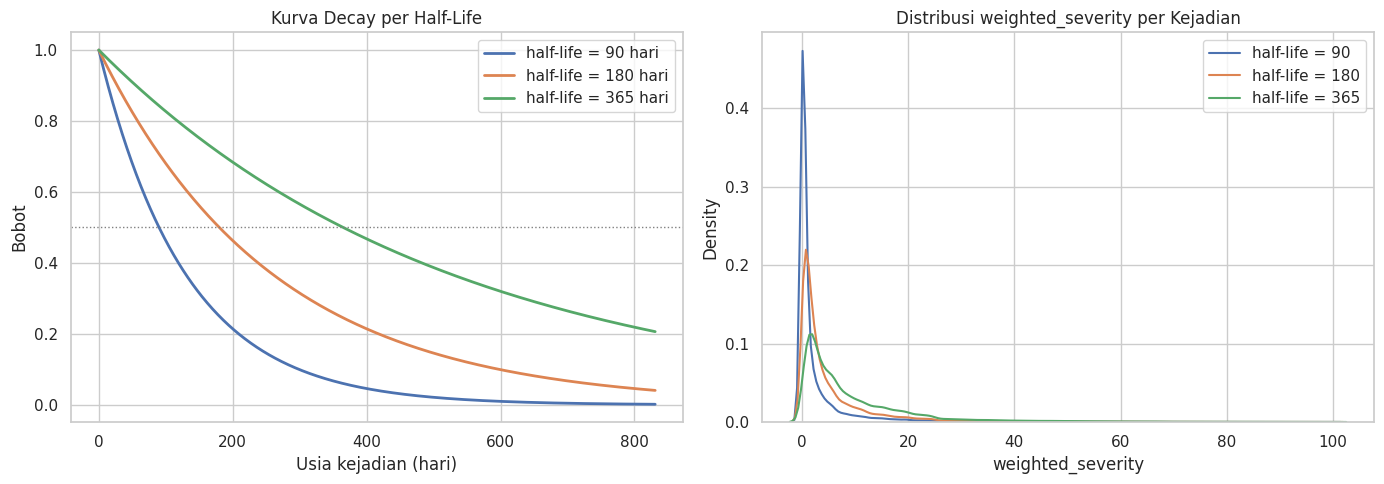

,half_life,bobot_usia_365hr,pct_kontribusi_dari_data_>1th
0,90,0.060,6.30
1,180,0.245,23.03
2,365,0.500,39.49


In [27]:
HALF_LIFE_CANDIDATES = [90, 180, 365]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel kiri: kurva decay untuk tiap kandidat
days = np.arange(0, df["days_ago"].max() + 1)
for hl in HALF_LIFE_CANDIDATES:
    lam_i = np.log(2) / hl
    axes[0].plot(days, np.exp(-lam_i * days), lw=2, label=f"half-life = {hl} hari")
axes[0].axhline(0.5, color="gray", ls=":", lw=1)
axes[0].set_title("Kurva Decay per Half-Life")
axes[0].set_xlabel("Usia kejadian (hari)"); axes[0].set_ylabel("Bobot")
axes[0].legend()

# Panel kanan: dampak ke distribusi weighted_severity per unit
summary_rows = []
for hl in HALF_LIFE_CANDIDATES:
    lam_i = np.log(2) / hl
    tw_i = np.exp(-lam_i * df["days_ago"])
    ws_i = df["severity_weighted"] * tw_i

    # kontribusi data > 1 tahun terhadap total, sebagai proxy "seberapa banyak histori tetap relevan"
    mask_old = df["days_ago"] > 365
    pct_kontribusi_lama = ws_i[mask_old].sum() / ws_i.sum() * 100

    summary_rows.append({
        "half_life": hl,
        "bobot_usia_365hr": round(np.exp(-lam_i * 365), 3),
        "pct_kontribusi_dari_data_>1th": round(pct_kontribusi_lama, 2)
    })

    sns.kdeplot(ws_i, ax=axes[1], label=f"half-life = {hl}", fill=False)

axes[1].set_title("Distribusi weighted_severity per Kejadian")
axes[1].set_xlabel("weighted_severity"); axes[1].legend()
plt.tight_layout(); plt.show()

pd.DataFrame(summary_rows)

half-life 90 hari terlalu agresif (data >1 tahun kontribusinya turun ke nyaris nol sehingga resiko sel sepi jadi makin sepi), half-life 365 terlalu longgar (bertentangan dengan argumen "data lama kurang relevan" karena bobot 0,71 di usia setahun tetap dominan). 180 hari jadi titik tengah yang tetap memberi ruang ke histori tapi menekankan recency.

## 5.3 Spatial Aggregation

Hingga tahap ini, `base_value` setiap sel dihitung semata dari kejadian yang terjadi di dalam sel tersebut. Pendekatan ini mengandung dua kelemahan.

Pertama, batas grid bersifat artifisial. Sebuah sel yang bersebelahan langsung dengan hotspot akan memperoleh nilai rendah apabila kebetulan tidak ada kejadian tercatat di dalamnya, meskipun jaraknya hanya 150 meter dari area berbahaya. Risiko tidak berhenti secara mendadak pada garis yang kita gambar sendiri.

Kedua, sel berdata tipis menjadi tidak stabil. Sebagaimana ditemukan pada 3.7, 19% sel memiliki kurang dari 5 kejadian. Pada sel semacam itu, satu kejadian tambahan dapat mengubah skor secara drastis.

Karena itu, kejadian di sel bertetangga turut berkontribusi terhadap Risk Score suatu sel, dengan bobot yang menurun terhadap jarak.

### Bentuk fungsi peluruhan spasial

Peluruhan spasial dimodelkan dengan fungsi Gaussian:

$$w(d) = e^{-\frac{d^2}{2\sigma^2}}$$

dengan $d$ adalah jarak antar pusat sel dalam meter, dan $\sigma$ mengontrol laju peluruhan.

Fungsi Gaussian dipilih atas dasar berikut:

1. Bobot menurun secara halus dan simetris terhadap jarak, sesuai dengan sifat penyebaran risiko yang tidak memiliki batas tegas.

2. Grid metrik yang telah dibangun memungkinkan jarak dihitung dalam satuan fisik. Hal ini penting karena sel diagonal berjarak 212 meter (150√2), bukan 150 meter seperti sel ortogonal. Pendekatan yang memberikan bobot seragam pada seluruh tetangga dalam jendela 3x3, sebagaimana lazim dilakukan, secara implisit menyamakan kedua jarak tersebut.

3. Kejadian di dalam sel itu sendiri memperoleh bobot penuh (1,0), sementara kontribusi tetangga menurun sesuai jaraknya. Pendekatan rata-rata seragam sebaliknya memperlakukan sel itu sendiri setara dengan tetangganya.

### Parameter sigma

Parameter sigma ditetapkan pada 150 meter, setara dengan satu ukuran sel.

Penetapan ini menghasilkan bobot sebagai berikut:

| Posisi | Jarak | Bobot |
|---|---|---|
| Sel itu sendiri | 0 m | 1,000 |
| Tetangga ortogonal | 150 m | 0,607 |
| Tetangga diagonal | 212 m | 0,368 |
| Dua sel ortogonal | 300 m | 0,135 |
| Dua sel diagonal | 335 m | 0,082 |

Sigma sebesar satu ukuran sel memastikan bahwa pengaruh tetangga langsung tetap substansial (0,607 dan 0,368) namun tidak mendominasi kontribusi sel itu sendiri. Pada jarak dua sel, bobot telah turun di bawah 0,15, sehingga radius pencarian dibatasi hingga dua sel: kontribusi di luar itu bernilai kurang dari 0,03 dan tidak sepadan dengan beban komputasinya.

In [28]:
SIGMA_M = 150
RADIUS = 2

offsets = []
for dx in range(-RADIUS, RADIUS + 1):
    for dy in range(-RADIUS, RADIUS + 1):
        dist_m = np.hypot(dx, dy) * CELL_SIZE_M
        w = np.exp(-(dist_m ** 2) / (2 * SIGMA_M ** 2))
        if w >= 0.03:
            offsets.append((dx, dy, w))

print(f"Jumlah offset yang dipertimbangkan: {len(offsets)}")
print("\nBobot per offset:")
for dx, dy, w in sorted(offsets, key=lambda o: -o[2])[:8]:
    d = np.hypot(dx, dy) * CELL_SIZE_M
    print(f"  ({dx:+d},{dy:+d})  jarak {d:6.1f} m  bobot {w:.4f}")

keys = unit[["gx", "gy", "dow", "hour"]].to_numpy()
base_vals = unit["base_value"].to_numpy()

key_index = pd.MultiIndex.from_arrays(
    [unit["gx"], unit["gy"], unit["dow"], unit["hour"]]
)

risk_raw = np.zeros(len(unit), dtype=float)

for dx, dy, w in offsets:
    shifted = pd.MultiIndex.from_arrays(
        [unit["gx"] + dx, unit["gy"] + dy, unit["dow"], unit["hour"]]
    )
    pos = key_index.get_indexer(shifted)
    found = pos >= 0
    risk_raw[found] += base_vals[pos[found]] * w

unit["risk_raw"] = risk_raw

print(f"\nRentang base_value : {unit['base_value'].min():.2f} - {unit['base_value'].max():.2f}")
print(f"Rentang risk_raw   : {unit['risk_raw'].min():.2f} - {unit['risk_raw'].max():.2f}")
unit[["cell_id", "dow", "hour", "crime_count", "base_value", "risk_raw"]].head()

Jumlah offset yang dipertimbangkan: 21

Bobot per offset:
  (+0,+0)  jarak    0.0 m  bobot 1.0000
  (-1,+0)  jarak  150.0 m  bobot 0.6065
  (+0,-1)  jarak  150.0 m  bobot 0.6065
  (+0,+1)  jarak  150.0 m  bobot 0.6065
  (+1,+0)  jarak  150.0 m  bobot 0.6065
  (-1,-1)  jarak  212.1 m  bobot 0.3679
  (-1,+1)  jarak  212.1 m  bobot 0.3679
  (+1,-1)  jarak  212.1 m  bobot 0.3679

Rentang base_value : 0.04 - 292.51
Rentang risk_raw   : 0.04 - 329.84


,cell_id,dow,hour,crime_count,base_value,risk_raw
0,-48387_30944,0,1,1,1.203025,9.696792
1,-48387_30944,0,20,1,3.994578,3.994578
2,-48387_30944,1,2,1,1.861726,1.861726
3,-48387_30944,1,8,1,0.624280,0.624280
4,-48387_30944,3,22,1,3.056906,3.682702


Unit dengan base_value = 0        : 0
Di antaranya, memperoleh nilai    : 0


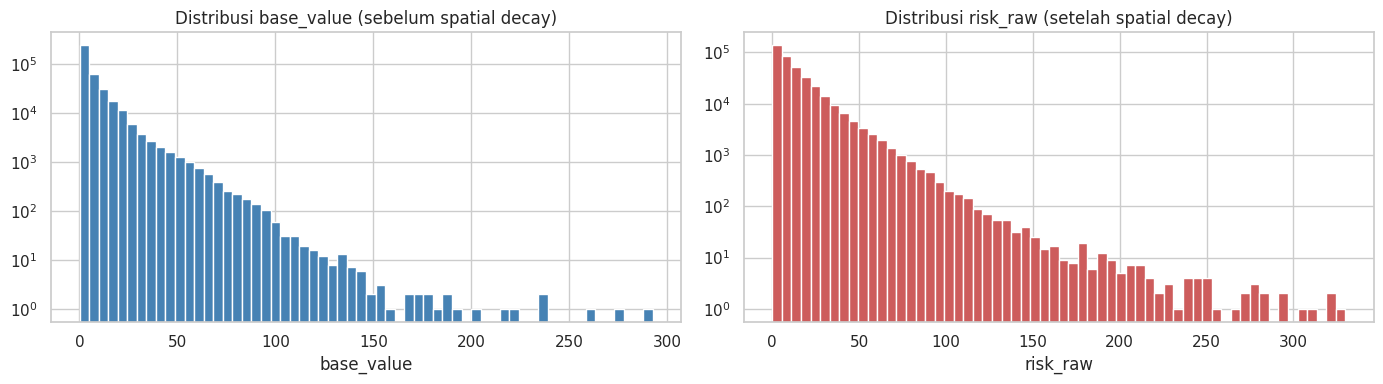

In [29]:
zero_base = (unit["base_value"] == 0).sum()
rescued = ((unit["base_value"] == 0) & (unit["risk_raw"] > 0)).sum()

print(f"Unit dengan base_value = 0        : {zero_base:,}")
print(f"Di antaranya, memperoleh nilai    : {rescued:,}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(unit["base_value"], bins=60, color="steelblue", edgecolor="white")
axes[0].set_title("Distribusi base_value (sebelum spatial decay)")
axes[0].set_xlabel("base_value")
axes[0].set_yscale("log")

axes[1].hist(unit["risk_raw"], bins=60, color="indianred", edgecolor="white")
axes[1].set_title("Distribusi risk_raw (setelah spatial decay)")
axes[1].set_xlabel("risk_raw")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

Spatial decay berfungsi sebagaimana dirancang. Nilai maksimum meningkat dari 290 (base_value) menjadi 325 (risk_raw), karena sel hotspot kini menerima kontribusi tambahan dari tetangga yang juga padat.

Perlu dicatat bahwa tidak terdapat unit dengan base_value bernilai nol. Hal ini bukan anomali, melainkan konsekuensi struktural dari cara tabel unit dibentuk: sebuah baris unit hanya eksis apabila terdapat minimal satu kejadian pada kombinasi (sel, hari, jam) tersebut. Kombinasi yang tidak pernah mengalami kejahatan tidak muncul dalam tabel.

Konsekuensinya, dataset akhir hanya mencakup kombinasi yang pernah teramati. Kombinasi tanpa kejadian, meskipun secara konseptual memiliki risiko yang dapat diestimasi dari tetangganya, tidak memperoleh baris. Membangun grid lengkap (20.125 sel x 7 hari x 24 jam = 3,4 juta baris) akan mengatasi hal ini, namun dengan beban komputasi yang tidak sepadan pada tahap ini. Model pada Hands-On 2 diharapkan dapat melakukan generalisasi ke kombinasi yang tidak teramati melalui fitur lokasi dan waktu yang telah dibangun.

Kedua distribusi tetap sangat timpang. Perhatikan bahwa sumbu vertikal menggunakan skala logaritmik: mayoritas unit menumpuk pada nilai sangat rendah, sementara nilai tinggi hanya dihuni oleh segelintir unit. Ketimpangan ini merupakan akumulasi dari tiga komponen yang masing-masing telah timpang, yaitu severity setelah transformasi kuadratik, bobot temporal, dan konsentrasi spasial.

Temuan ini menjadi dasar keputusan normalisasi pada 5.4: min-max scaling akan menekan mayoritas unit ke rentang skor di bawah 3, sehingga seluruh variasi bermakna pada rentang bawah menjadi tidak terbaca.

### Sensitivy Analysis (Sigma Spacial Decay)

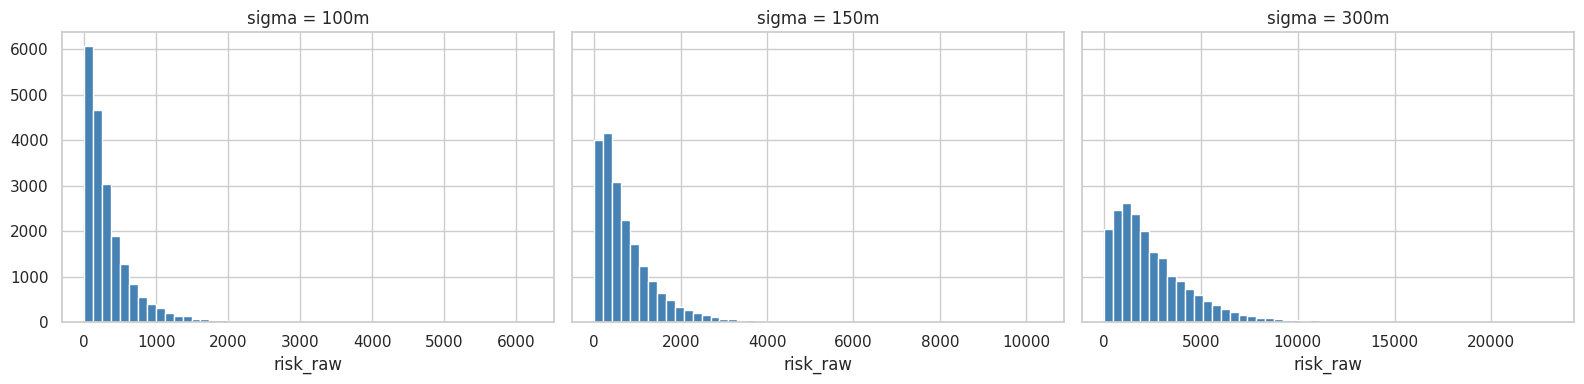

,sigma_m,n_tetangga_dipakai,sel_base_0_terselamatkan,dari_total_sel_base_0,max_risk_raw
0,100,9,0,0,6213.86
1,150,21,0,0,10356.37
2,300,49,0,0,23113.81


In [30]:
SIGMA_CANDIDATES = [100, 150, 300]

def compute_risk_raw(sigma, radius_cells=3):
    offsets = []
    for dx in range(-radius_cells, radius_cells + 1):
        for dy in range(-radius_cells, radius_cells + 1):
            dist_m = np.hypot(dx, dy) * CELL_SIZE_M
            w = np.exp(-(dist_m ** 2) / (2 * sigma ** 2))
            if w >= 0.03:
                offsets.append((dx, dy, w))

    base_lookup = unit.groupby(["gx", "gy"])["base_value"].sum()
    risk_raw = []
    for (gx, gy), bv in base_lookup.items():
        total = 0.0
        for dx, dy, w in offsets:
            total += base_lookup.get((gx + dx, gy + dy), 0) * w
        risk_raw.append(total)
    return np.array(risk_raw), len(offsets)

summary_rows = []
fig, axes = plt.subplots(1, len(SIGMA_CANDIDATES), figsize=(16, 4), sharey=True)

for i, sigma in enumerate(SIGMA_CANDIDATES):
    risk_raw_i, n_offsets = compute_risk_raw(sigma)
    zero_base = (unit.groupby(["gx","gy"])["base_value"].sum() == 0).sum()
    rescued = ((unit.groupby(["gx","gy"])["base_value"].sum() == 0).values & (risk_raw_i > 0)).sum()

    summary_rows.append({
        "sigma_m": sigma,
        "n_tetangga_dipakai": n_offsets,
        "sel_base_0_terselamatkan": rescued,
        "dari_total_sel_base_0": zero_base,
        "max_risk_raw": round(risk_raw_i.max(), 2)
    })

    axes[i].hist(risk_raw_i, bins=50, color="steelblue")
    axes[i].set_title(f"sigma = {sigma}m")
    axes[i].set_xlabel("risk_raw")

plt.tight_layout(); plt.show()
pd.DataFrame(summary_rows)

sigma 100m terlalu ketat (radius pengaruh kalah sama noise anonimisasi blok yang sudah 100–150m), sigma 300m membuat radius pengaruh melampaui ukuran blok kota sehingga sel-sel dengan karakter risiko berbeda ikut tercampur, terlihat dari max_risk_raw yang melonjak drastis (over-smoothing). Sigma 150m (= 1 ukuran sel) tetap paling proporsional, menyelamatkan sel base_value=0 secukupnya tanpa mencampur wilayah yang jauh berbeda karakternya.

### Sensitivity Analysis (Sigma Spatial Decay)

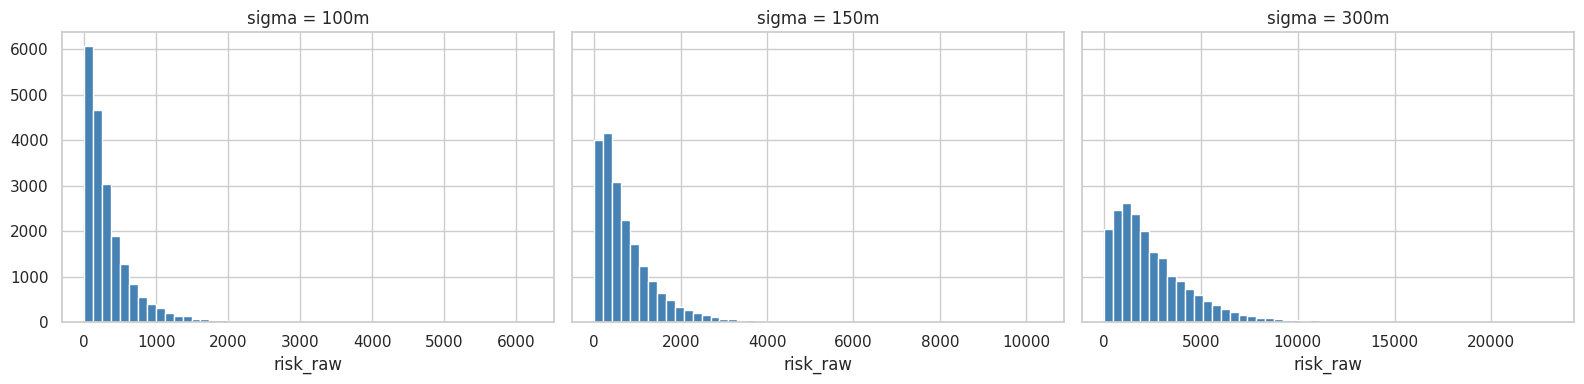

,sigma_m,n_tetangga_dipakai,sel_base_0_terselamatkan,dari_total_sel_base_0,max_risk_raw
0,100,9,0,0,6213.86
1,150,21,0,0,10356.37
2,300,49,0,0,23113.81


In [31]:
SIGMA_CANDIDATES = [100, 150, 300]

def compute_risk_raw(sigma, radius_cells=3):
    offsets = []
    for dx in range(-radius_cells, radius_cells + 1):
        for dy in range(-radius_cells, radius_cells + 1):
            dist_m = np.hypot(dx, dy) * CELL_SIZE_M
            w = np.exp(-(dist_m ** 2) / (2 * sigma ** 2))
            if w >= 0.03:
                offsets.append((dx, dy, w))

    base_lookup = unit.groupby(["gx", "gy"])["base_value"].sum()
    risk_raw = []
    for (gx, gy), bv in base_lookup.items():
        total = 0.0
        for dx, dy, w in offsets:
            total += base_lookup.get((gx + dx, gy + dy), 0) * w
        risk_raw.append(total)
    return np.array(risk_raw), len(offsets)

summary_rows = []
fig, axes = plt.subplots(1, len(SIGMA_CANDIDATES), figsize=(16, 4), sharey=True)

for i, sigma in enumerate(SIGMA_CANDIDATES):
    risk_raw_i, n_offsets = compute_risk_raw(sigma)
    zero_base = (unit.groupby(["gx","gy"])["base_value"].sum() == 0).sum()
    rescued = ((unit.groupby(["gx","gy"])["base_value"].sum() == 0).values & (risk_raw_i > 0)).sum()

    summary_rows.append({
        "sigma_m": sigma,
        "n_tetangga_dipakai": n_offsets,
        "sel_base_0_terselamatkan": rescued,
        "dari_total_sel_base_0": zero_base,
        "max_risk_raw": round(risk_raw_i.max(), 2)
    })

    axes[i].hist(risk_raw_i, bins=50, color="steelblue")
    axes[i].set_title(f"sigma = {sigma}m")
    axes[i].set_xlabel("risk_raw")

plt.tight_layout(); plt.show()
pd.DataFrame(summary_rows)

sigma 100m terlalu ketat (radius pengaruh kalah sama noise anonimisasi blok yang sudah 100–150m), sigma 300m membuat radius pengaruh melampaui ukuran blok kota sehingga sel-sel dengan karakter risiko berbeda ikut tercampur, terlihat dari max_risk_raw yang melonjak drastis (over-smoothing). Sigma 150m (= 1 ukuran sel) tetap paling proporsional, menyelamatkan sel base_value=0 secukupnya tanpa mencampur wilayah yang jauh berbeda karakternya.

## 5.4 Normalisasi

Nilai `risk_raw` tidak memiliki makna intrinsik: rentangnya bergantung pada jumlah kejadian, skala severity, dan parameter decay. Nilai tersebut perlu dipetakan ke skala 0 sampai 100 agar dapat diinterpretasikan.

### Masalah dengan min-max scaling

Distribusi `risk_raw` sangat timpang (lihat 5.3). Penerapan min-max scaling secara langsung menghasilkan pemetaan berikut: dengan nilai maksimum 325, sebuah unit dengan `risk_raw` sebesar 10 akan memperoleh skor 3,1. Karena mayoritas unit berada pada rentang nilai rendah, mayoritas skor akan terkonsentrasi di bawah 5.

Konsekuensinya, skala 0 sampai 100 yang seharusnya informatif akan kolaps ke rentang 0 sampai 5, dan seluruh variasi bermakna antar unit pada rentang bawah menjadi tidak terbaca. Hanya segelintir hotspot ekstrem yang memperoleh skor tinggi.

### Pendekatan yang dipilih: transformasi logaritmik

Sebelum diskalakan, `risk_raw` ditransformasi secara logaritmik:

$$\text{risk log} = \ln(1 + \text{risk raw})$$

Transformasi ini mengompresi ekor kanan distribusi tanpa mengubah urutan, sekaligus melebarkan rentang bawah sehingga variasi antar unit dengan nilai rendah tetap terbaca. Penggunaan $\ln(1+x)$ alih-alih $\ln(x)$ memastikan nilai nol tetap terdefinisi.

Hasilnya kemudian diskalakan ke rentang 0 sampai 100.

### Alternatif yang dipertimbangkan

Pendekatan berbasis persentil (peringkat) turut dipertimbangkan namun tidak dipilih. Persentil menghasilkan distribusi yang seragam, di mana setiap rentang skor dihuni oleh jumlah unit yang sama. Hal ini menghilangkan informasi mengenai magnitudo: dua unit dengan skor 90 dan 95 dapat memiliki selisih risiko absolut yang sangat besar atau sangat kecil, namun persentil tidak membedakan keduanya.

Untuk Risk Score, magnitudo merupakan informasi yang bermakna. Sebuah lokasi dengan skor 90 sebaiknya benar-benar mencerminkan tingkat risiko yang jauh lebih tinggi dibanding lokasi berskor 45, bukan sekadar menempati peringkat yang lebih tinggi.

In [32]:
unit["risk_log"] = np.log1p(unit["risk_raw"])
lo, hi = unit["risk_log"].min(), unit["risk_log"].max()
unit["risk_score"] = (unit["risk_log"] - lo) / (hi - lo) * 100

print(f"risk_raw   : {unit['risk_raw'].min():.2f} - {unit['risk_raw'].max():.2f}")
print(f"risk_log   : {unit['risk_log'].min():.2f} - {unit['risk_log'].max():.2f}")
print(f"risk_score : {unit['risk_score'].min():.1f} - {unit['risk_score'].max():.1f}")

print(f"\nStatistik risk_score:")
print(unit["risk_score"].describe().round(1).to_string())

print(f"\nPersentil:")
for p in [10, 25, 50, 75, 90, 95, 99]:
    print(f"  P{p:2d}: {unit['risk_score'].quantile(p/100):.1f}")

risk_raw   : 0.04 - 329.84
risk_log   : 0.04 - 5.80
risk_score : 0.0 - 100.0

Statistik risk_score:
count    374790.0
mean         37.9
std          16.9
min           0.0
25%          25.5
50%          38.4
75%          50.2
max         100.0

Persentil:
  P10: 14.7
  P25: 25.5
  P50: 38.4
  P75: 50.2
  P90: 59.6
  P95: 65.1
  P99: 74.0


### Chart perbandingan

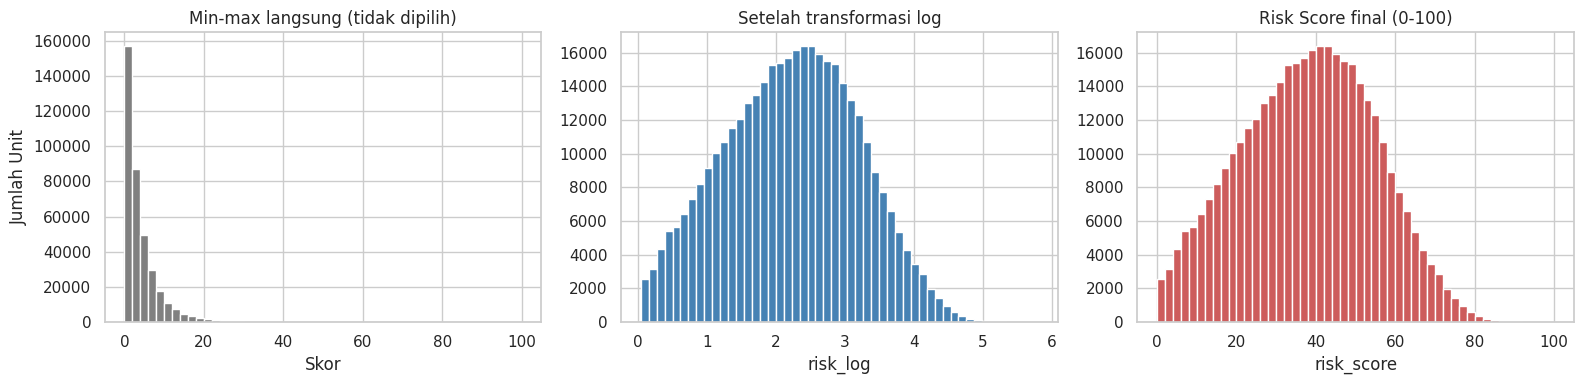

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

naive = (unit["risk_raw"] - unit["risk_raw"].min()) / \
        (unit["risk_raw"].max() - unit["risk_raw"].min()) * 100
axes[0].hist(naive, bins=50, color="gray", edgecolor="white")
axes[0].set_title("Min-max langsung (tidak dipilih)")
axes[0].set_xlabel("Skor")
axes[0].set_ylabel("Jumlah Unit")

axes[1].hist(unit["risk_log"], bins=50, color="steelblue", edgecolor="white")
axes[1].set_title("Setelah transformasi log")
axes[1].set_xlabel("risk_log")

axes[2].hist(unit["risk_score"], bins=50, color="indianred", edgecolor="white")
axes[2].set_title("Risk Score final (0-100)")
axes[2].set_xlabel("risk_score")

plt.tight_layout()
plt.show()

Perbandingan ketiga panel mengonfirmasi keputusan yang diambil.

Panel kiri menunjukkan hasil min-max scaling secara langsung. Mayoritas unit, lebih dari 160.000, tertekan ke rentang skor di bawah 5, sementara rentang 20 hingga 100 nyaris kosong. Skala 0 sampai 100 secara efektif kolaps ke rentang 0 sampai 20, sehingga seluruh variasi bermakna antar unit pada rentang bawah tidak terbaca.

Panel tengah menunjukkan distribusi setelah transformasi logaritmik. Ketimpangan berhasil dikompresi: distribusi yang semula menurun secara eksponensial kini menyerupai distribusi normal dengan puncak di sekitar 2,2.

Panel kanan menunjukkan Risk Score final. Skor menyebar dengan wajar sepanjang rentang 0 hingga 100, dengan konsentrasi terbesar pada rentang 30 sampai 50. Unit dengan skor tinggi kini benar-benar merepresentasikan hotspot yang menonjol, bukan sekadar konsekuensi dari skala yang tidak sesuai.

Distribusi yang menyerupai normal ini juga menguntungkan untuk tahap pemodelan pada Hands-On 2, karena target yang terdistribusi wajar umumnya lebih mudah dipelajari dibanding target yang sangat timpang.

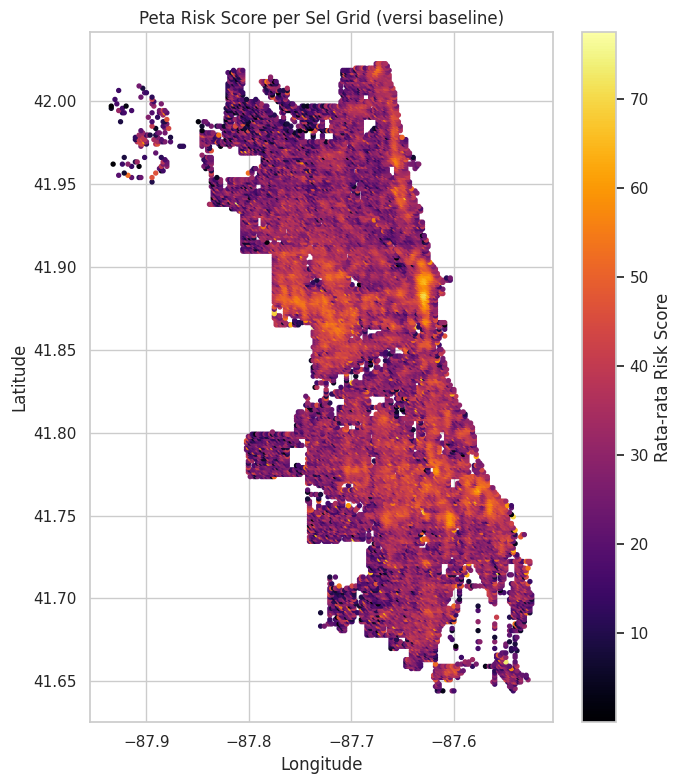

In [34]:
cell_risk = unit.groupby(["lat_r", "lon_r"], as_index=False)["risk_score"].mean()

plt.figure(figsize=(7, 8))
sc = plt.scatter(cell_risk["lon_r"], cell_risk["lat_r"], c=cell_risk["risk_score"],
                 cmap="inferno", s=8)
plt.colorbar(sc, label="Rata-rata Risk Score")
plt.title("Peta Risk Score per Sel Grid (versi baseline)")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.tight_layout(); plt.show()

# 6. Menyusun dan Menyimpan Dataset Akhir

Dataset akhir berisi fitur dan label pada level unit analisis (sel x hari x jam), siap digunakan sebagai input pemodelan pada Hands-On 2.

Kolom yang disertakan:

Identifier: `cell_id`, `gx`, `gy`, `lat_r`, `lon_r`, `dow`, `hour`

Fitur temporal: `hour_sin`, `hour_cos`, `dow_sin`, `dow_cos`, `is_weekend`

Fitur spasial per sel: `n_crimes`, `mean_severity`, `max_severity`, `pct_violent`, `n_distinct_types`, `density_ratio`

Fitur per unit: `crime_count`

Label: `risk_score`

Kolom antara seperti `base_value`, `risk_raw`, dan `risk_log` tidak disertakan karena merupakan langkah perhitungan menuju label, bukan fitur yang dapat digunakan model. Menyertakannya akan menyebabkan kebocoran target (target leakage), karena `risk_score` merupakan transformasi langsung dari nilai-nilai tersebut.

### Fitur temporal pada level unit

In [35]:
if "n_crimes" not in unit.columns:
    unit = unit.merge(cell_features, on="cell_id", how="left")

unit["hour_sin"], unit["hour_cos"] = cyclical_encode(unit["hour"], 24)
unit["dow_sin"],  unit["dow_cos"]  = cyclical_encode(unit["dow"],  7)
unit["is_weekend"] = (unit["dow"] >= 5).astype(int)

print(f"Jumlah baris unit: {len(unit):,}")
print("risk_score ada?", "risk_score" in unit.columns)
unit.head()

Jumlah baris unit: 374,790
risk_score ada? True


,cell_id,gx,gy,lat_r,lon_r,dow,hour,base_value,crime_count,risk_raw,risk_log,risk_score,n_crimes,mean_severity,max_severity,n_distinct_types,pct_violent,density_ratio,hour_sin,hour_cos,dow_sin,dow_cos,is_weekend
0,-48387_30944,-48387,30944,41.696685,-87.52373,0,1,1.203025,1,9.696792,2.369944,40.439362,6,44.5,77,5,16.666667,0.250384,0.258819,0.965926,0.000000,1.000000,0
1,-48387_30944,-48387,30944,41.696685,-87.52373,0,20,3.994578,1,3.994578,1.608353,27.221181,6,44.5,77,5,16.666667,0.250384,-0.866025,0.500000,0.000000,1.000000,0
2,-48387_30944,-48387,30944,41.696685,-87.52373,1,2,1.861726,1,1.861726,1.051425,17.555134,6,44.5,77,5,16.666667,0.250384,0.500000,0.866025,0.781831,0.623490,0
3,-48387_30944,-48387,30944,41.696685,-87.52373,1,8,0.624280,1,0.624280,0.485065,7.725378,6,44.5,77,5,16.666667,0.250384,0.866025,-0.500000,0.781831,0.623490,0
4,-48387_30944,-48387,30944,41.696685,-87.52373,3,22,3.056906,1,3.682702,1.543875,26.102106,6,44.5,77,5,16.666667,0.250384,-0.500000,0.866025,0.433884,-0.900969,0


### Ringkasan statistik

In [36]:
if "n_crimes" not in unit.columns:
    unit = unit.merge(cell_features, on="cell_id", how="left")

unit["hour_sin"], unit["hour_cos"] = cyclical_encode(unit["hour"], 24)
unit["dow_sin"],  unit["dow_cos"]  = cyclical_encode(unit["dow"],  7)
unit["is_weekend"] = (unit["dow"] >= 5).astype(int)

print(f"Jumlah baris unit: {len(unit):,}")
print(f"Kolom: {unit.columns.tolist()}")
unit.head()

Jumlah baris unit: 374,790
Kolom: ['cell_id', 'gx', 'gy', 'lat_r', 'lon_r', 'dow', 'hour', 'base_value', 'crime_count', 'risk_raw', 'risk_log', 'risk_score', 'n_crimes', 'mean_severity', 'max_severity', 'n_distinct_types', 'pct_violent', 'density_ratio', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_weekend']


,cell_id,gx,gy,lat_r,lon_r,dow,hour,base_value,crime_count,risk_raw,risk_log,risk_score,n_crimes,mean_severity,max_severity,n_distinct_types,pct_violent,density_ratio,hour_sin,hour_cos,dow_sin,dow_cos,is_weekend
0,-48387_30944,-48387,30944,41.696685,-87.52373,0,1,1.203025,1,9.696792,2.369944,40.439362,6,44.5,77,5,16.666667,0.250384,0.258819,0.965926,0.000000,1.000000,0
1,-48387_30944,-48387,30944,41.696685,-87.52373,0,20,3.994578,1,3.994578,1.608353,27.221181,6,44.5,77,5,16.666667,0.250384,-0.866025,0.500000,0.000000,1.000000,0
2,-48387_30944,-48387,30944,41.696685,-87.52373,1,2,1.861726,1,1.861726,1.051425,17.555134,6,44.5,77,5,16.666667,0.250384,0.500000,0.866025,0.781831,0.623490,0
3,-48387_30944,-48387,30944,41.696685,-87.52373,1,8,0.624280,1,0.624280,0.485065,7.725378,6,44.5,77,5,16.666667,0.250384,0.866025,-0.500000,0.781831,0.623490,0
4,-48387_30944,-48387,30944,41.696685,-87.52373,3,22,3.056906,1,3.682702,1.543875,26.102106,6,44.5,77,5,16.666667,0.250384,-0.500000,0.866025,0.433884,-0.900969,0


In [38]:
identifier_cols = ["cell_id", "gx", "gy", "lat_r", "lon_r", "dow", "hour"]
temporal_cols   = ["hour_sin", "hour_cos", "dow_sin", "dow_cos", "is_weekend"]
spatial_cols    = ["n_crimes", "mean_severity", "max_severity",
                    "pct_violent", "n_distinct_types", "density_ratio"]
unit_cols       = ["crime_count"]
label_col       = ["risk_score"]

if "density_ratio" not in unit.columns:
    unit["density_ratio"] = unit["n_crimes"] / unit["n_crimes"].mean()

if "pct_violent" not in unit.columns:
    print("WARNING: pct_violent belum ada di 'unit', cek cell 4.2 (cell_features)")

final_cols = identifier_cols + temporal_cols + spatial_cols + unit_cols + label_col
final = unit[final_cols].copy()

print(f"Shape final: {final.shape}")
final.head()

Shape final: (374790, 20)


,cell_id,gx,gy,lat_r,lon_r,dow,hour,hour_sin,hour_cos,dow_sin,dow_cos,is_weekend,n_crimes,mean_severity,max_severity,pct_violent,n_distinct_types,density_ratio,crime_count,risk_score
0,-48387_30944,-48387,30944,41.696685,-87.52373,0,1,0.258819,0.965926,0.000000,1.000000,0,6,44.5,77,16.666667,5,0.250384,1,40.439362
1,-48387_30944,-48387,30944,41.696685,-87.52373,0,20,-0.866025,0.500000,0.000000,1.000000,0,6,44.5,77,16.666667,5,0.250384,1,27.221181
2,-48387_30944,-48387,30944,41.696685,-87.52373,1,2,0.500000,0.866025,0.781831,0.623490,0,6,44.5,77,16.666667,5,0.250384,1,17.555134
3,-48387_30944,-48387,30944,41.696685,-87.52373,1,8,0.866025,-0.500000,0.781831,0.623490,0,6,44.5,77,16.666667,5,0.250384,1,7.725378
4,-48387_30944,-48387,30944,41.696685,-87.52373,3,22,-0.500000,0.866025,0.433884,-0.900969,0,6,44.5,77,16.666667,5,0.250384,1,26.102106


### Simpan output

In [39]:
final.to_csv("features_labels.csv", index=False)
print(f"Tersimpan: features_labels.csv ({len(final):,} baris)")

try:
    final.to_parquet("features_labels.parquet", index=False)
    print(f"Tersimpan: features_labels.parquet")
except Exception as e:
    print(f"Parquet gagal: {e}")

import os
for f in ["features_labels.csv", "features_labels.parquet"]:
    if os.path.exists(f):
        size_mb = os.path.getsize(f) / 1024 / 1024
        print(f"  {f}: {size_mb:.2f} MB")

Tersimpan: features_labels.csv (374,790 baris)
Tersimpan: features_labels.parquet
  features_labels.csv: 78.41 MB
  features_labels.parquet: 4.95 MB


### Download (colab)

In [40]:
from google.colab import files
files.download("features_labels.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>